# Project1 - LangGraph RAG With Semantic Hierarchical Chunking

- Stack: LangGraph, Qdrant
- We add metadata of the hierarchy so that each chunk, no matter if it is imperfectly chunked, can be fed to LLM
- The LLMs are more capable to fix some issues with unclean chunks as it understands the language and can tell if a heading is incorrectly mentioned for a paragraph.

In [ ]:
# 1. First install GPU-enabled PyTorch from its specific CUDA wheel registry
!pip install -qU torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# 2. Install all remaining ecosystem packages from standard PyPI in a single clean pass
!pip install -qU \
    transformers tokenizers huggingface_hub \
    sentence_transformers fastembed \
    bitsandbytes \
    qdrant-client \
    docling pypdf pymupdf==1.25.1 pymupdf4llm \
    langchain langchain-core langchain-community langchain-text-splitters \
    langchain-qdrant langchain-huggingface langchain-pymupdf4llm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 124.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.9/588.9 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.0/520.0 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.5/343.5 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/461.3 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 118.0 MB/s eta 0:00:0

In [ ]:
!pip freeze | grep fastembed

fastembed==0.8.0


# Hierarchical Chunking Approach

## Using Docling For GPU Accelerated Parsing

- `torchvision` is used for doing ocr
- `torchaudio` is used for speech to text and multimodal RAG. Here it is optional so, we can even ignore it.

- We use the cuda 12.1 version which works well and is a known stable version.

In [ ]:
!pip freeze | grep docling

docling==2.95.0
docling-core==2.77.0
docling-ibm-models==3.13.2
docling-parse==5.11.0
docling-slim==2.95.0


### Hierarchical Chunking Using Docling

- Docs: https://deepwiki.com/docling-project/docling-core/4.2.3-hierarchical-chunking

In [ ]:
import os
import gc
import json
import re
import ctypes
import pypdf
import torch
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions, AcceleratorOptions
from docling.datamodel.accelerator_options import AcceleratorDevice
from docling.chunking import HierarchicalChunker
from langchain_core.documents import Document

# ==========================================
# 1. UTILITIES & CONFIGURATION
# ==========================================
SOURCE_PDF = "medical_diagnosis_manual.pdf"
OUTPUT_JSONL = "hierarchical_medical_chunks.jsonl"
BATCH_SIZE = 40

# Compiled regex pattern to strip out watermark text dynamically
DISCLAIMER_PATTERN = re.compile(
    r"This file is meant for personal use by adarshofficial11@gmail\.com only\."
    r"|Sharing or publishing the contents in part or full is liable for legal action\."
    r"|adarshofficial11@gmail\.com|O14FNU7EVB"
)

def deep_mem_clean():
    """Triple-threat memory cleanup for long-running PDF processing."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    try:
        libc = ctypes.CDLL("libc.so.6")
        libc.malloc_trim(0)
    except Exception:
        pass

# Initialize Docling infrastructure
pipeline_options = PdfPipelineOptions()
pipeline_options.accelerator_options = AcceleratorOptions(device=AcceleratorDevice.CUDA)
pipeline_options.do_ocr = False

converter = DocumentConverter(
    format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)}
)
chunker = HierarchicalChunker()  # Fixed: Removed non-standard argument

# Get total page count
with open(SOURCE_PDF, "rb") as f:
    total_pages = len(pypdf.PdfReader(f).pages)

# ==========================================
# 2. DYNAMIC RESUME LOGIC
# ==========================================
start_page = 1
if os.path.exists(OUTPUT_JSONL) and os.path.getsize(OUTPUT_JSONL) > 0:
    print(f"🔄 Found existing output file: {OUTPUT_JSONL}. Calculating resume point...")
    try:
        with open(OUTPUT_JSONL, "r", encoding="utf-8") as f:
            for line in f:
                pass  # Fast-forward to the very last line
            last_data = json.loads(line)
            last_processed_end_page = int(last_data["metadata"]["batch"].split("-")[1])
            start_page = last_processed_end_page + 1
    except Exception as e:
        print(f"⚠️ Could not automatically read last line due to: {e}. Defaulting to page 1.")
        start_page = 1

# ==========================================
# 3. CORE STREAMING & SANITIZATION PIPELINE
# ==========================================
if start_page > total_pages:
    print(f"🎉 Complete! All {total_pages} pages have already been processed in {OUTPUT_JSONL}.")
else:
    print(f"🚀 Processing from page {start_page} to {total_pages}...")
    file_mode = "a" if start_page > 1 else "w"

    with open(OUTPUT_JSONL, file_mode, encoding="utf-8") as f:
        for start in range(start_page, total_pages + 1, BATCH_SIZE):
            end = min(start + BATCH_SIZE - 1, total_pages)
            print(f"🛠️ Processing Batch: {start}-{end} | GPU VRAM Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")

            try:
                result = converter.convert(SOURCE_PDF, page_range=(start, end))
                docling_chunks = list(chunker.chunk(result.document))

                for chunk in docling_chunks:
                    # Resolve hierarchical context pathways
                    heading_list = [h.text if hasattr(h, 'text') else str(h) for h in (chunk.meta.headings or [])]
                    header_path = " > ".join(heading_list) if heading_list else "General"

                    # Extract page origin arrays safely
                    page_numbers = [p.page_no for p in chunk.meta.doc_items[0].prov] if chunk.meta.doc_items else []

                    # CRITICAL ON-THE-FLY CLEANING STEP
                    # Strip personal watermarks before committing data to memory or disk
                    sanitized_text = DISCLAIMER_PATTERN.sub("", chunk.text).strip()

                    # Skip writing completely if the text block becomes empty after cleaning
                    if not sanitized_text:
                        continue

                    # Stream structured payload to local disk
                    f.write(json.dumps({
                        "text": sanitized_text,
                        "metadata": {
                            "header_path": header_path,
                            "page_numbers": page_numbers,
                            "batch": f"{start}-{end}"
                        }
                    }) + "\n")

                # Context destruction to prevent memory leaks
                del result, docling_chunks
                deep_mem_clean()

            except Exception as e:
                print(f"❌ Error at batch {start}-{end}: {e}")
                deep_mem_clean()
                continue

    print(f"✅ Success! Data safely streamed to {OUTPUT_JSONL}")

# ==========================================
# 4. INSTANT LANGCHAIN DOCUMENT INGESTION
# ==========================================
def load_sanitized_langchain_documents(filepath):
    """
    Reads the sanitized JSONL file directly into standard LangChain Document
    objects, perfectly formatting them for your downstream vector store.
    """
    documents = []
    print(f"\n📥 Transforming lines from {filepath} into LangChain Document instances...")

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            data = json.loads(line)

            doc = Document(
                page_content=data["text"],
                metadata={
                    "header_path": data["metadata"].get("header_path"),
                    "page_numbers": data["metadata"].get("page_numbers"),
                    "source": SOURCE_PDF
                }
            )
            documents.append(doc)

    print(f"🏆 Successfully initialized {len(documents)} clean LangChain structures!")
    return documents

# Execute final array transformation pass
final_chunks = load_sanitized_langchain_documents(OUTPUT_JSONL)

🚀 Processing from page 1 to 4114...
🛠️ Processing Batch: 1-40 | GPU VRAM Allocated: 0.00 GB


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

🛠️ Processing Batch: 41-80 | GPU VRAM Allocated: 0.40 GB
🛠️ Processing Batch: 81-120 | GPU VRAM Allocated: 0.40 GB
🛠️ Processing Batch: 121-160 | GPU VRAM Allocated: 0.40 GB
🛠️ Processing Batch: 161-200 | GPU VRAM Allocated: 0.40 GB
🛠️ Processing Batch: 201-240 | GPU VRAM Allocated: 0.40 GB
🛠️ Processing Batch: 241-280 | GPU VRAM Allocated: 0.40 GB
🛠️ Processing Batch: 281-320 | GPU VRAM Allocated: 0.40 GB
🛠️ Processing Batch: 321-360 | GPU VRAM Allocated: 0.40 GB
🛠️ Processing Batch: 361-400 | GPU VRAM Allocated: 0.40 GB
🛠️ Processing Batch: 401-440 | GPU VRAM Allocated: 0.40 GB
🛠️ Processing Batch: 441-480 | GPU VRAM Allocated: 0.40 GB
🛠️ Processing Batch: 481-520 | GPU VRAM Allocated: 0.40 GB
🛠️ Processing Batch: 521-560 | GPU VRAM Allocated: 0.40 GB
🛠️ Processing Batch: 561-600 | GPU VRAM Allocated: 0.40 GB
🛠️ Processing Batch: 601-640 | GPU VRAM Allocated: 0.40 GB
🛠️ Processing Batch: 641-680 | GPU VRAM Allocated: 0.40 GB
🛠️ Processing Batch: 681-720 | GPU VRAM Allocated: 0.40 GB


In [ ]:
import random

def check_breadcrumbs(chunks, n=3):
    samples = random.sample(chunks, n)
    print(f"\n{'='*20} BREADCRUMB VERIFICATION {'='*20}")
    for i, c in enumerate(samples):
        print(f"CHUNK {i+1} PATH: {c.metadata['header_path']}")
        print(f"PAGE(S): {c.metadata['page_numbers']}")
        print(f"CONTENT: {c.page_content[c.page_content.find('\\n\\n')+2:200]}...")
        print("-" * 60)

check_breadcrumbs(final_chunks)


==================== BREADCRUMB VERIFICATION ====================
CHUNK 1 PATH: Juvenile Hemochromatosis
PAGE(S): [1184]
CONTENT: uvenile hemochromatosis is a rare autosomal recessive disorder caused by mutations in the HJV gene that affect the transcription protein hemojuvelin. It often manifests in adolescents. Symptoms and s...
------------------------------------------------------------
CHUNK 2 PATH: Symptoms and Signs
PAGE(S): [2341]
CONTENT: he murmur of PR due to pulmonary hypertension is a high-pitched, early diastolic decrescendo murmur that begins with P 2  and ends before S 1  and that radiates toward the mid-right sternal edge (Gra...
------------------------------------------------------------
CHUNK 3 PATH: Drugs for ACLS
PAGE(S): [2416]
CONTENT: rocainamide is a 2nd-line drug for treatment of refractory VF or VT. However, procainamide is not recommended for pulseless arrest in children....
------------------------------------------------------------


In [ ]:
import json
import pandas as pd
from collections import Counter

def analyze_hierarchy_depth(filepath):
    depths = []
    paths = []

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            data = json.loads(line)
            path = data["metadata"].get("header_path", "General")
            paths.append(path)
            # Count the number of ' > ' separators to determine depth
            depths.append(path.count(" > ") + 1)

    stats = Counter(depths)
    print(f"{'='*20} HIERARCHY DEPTH ANALYSIS {'='*20}")
    for d, count in sorted(stats.items()):
        print(f"Level {d} (e.g., {' > '.join(['Section']*d)}): {count} chunks")

    print(f"\nTop 5 Most Populated Paths:")
    for path, count in Counter(paths).most_common(5):
        print(f" - [{count} chunks]: {path}")

analyze_hierarchy_depth("hierarchical_medical_chunks.jsonl")

==================== HIERARCHY DEPTH ANALYSIS ====================
Level 1 (e.g., Section): 38020 chunks
Level 2 (e.g., Section > Section): 25 chunks

Top 5 Most Populated Paths:
 - [6299 chunks]: Treatment
 - [4500 chunks]: Diagnosis
 - [2727 chunks]: Symptoms and Signs
 - [2053 chunks]: Evaluation
 - [2023 chunks]: Etiology


In [ ]:
import random

def check_semantic_continuity(filepath, n_samples=3):
    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    samples = random.sample(lines, min(n_samples, len(lines)))

    print(f"{'='*20} SEMANTIC CONTINUITY CHECK {'='*20}")
    for i, line in enumerate(samples):
        data = json.loads(line)
        meta = data["metadata"]

        print(f"\nSAMPLE {i+1}")
        print(f"📍 LOCATION: Page(s) {meta.get('page_numbers')} | Batch: {meta.get('batch')}")
        print(f"📂 HIERARCHY: {meta.get('header_path')}")
        print(f"📝 TEXT PREVIEW: {data['text'][:300]}...")
        print("-" * 60)

check_semantic_continuity("hierarchical_medical_chunks.jsonl")

==================== SEMANTIC CONTINUITY CHECK ====================

SAMPLE 1
📍 LOCATION: Page(s) [947] | Batch: 921-960
📂 HIERARCHY: Classification
📝 TEXT PREVIEW: - Type 1 diabetes (autoimmune etiology)...
------------------------------------------------------------

SAMPLE 2
📍 LOCATION: Page(s) [2939] | Batch: 2921-2960
📂 HIERARCHY: Perinatal Anemia
📝 TEXT PREVIEW: neonate relative to the placenta before...
------------------------------------------------------------

SAMPLE 3
📍 LOCATION: Page(s) [442] | Batch: 441-480
📂 HIERARCHY: Diagnosis
📝 TEXT PREVIEW: Laboratory studies are normal in OA but may be required to rule out other disorders (eg, RA) or to diagnose an underlying disorder causing secondary OA. If OA causes joint effusions, synovial fluid analysis can help differentiate it from inflammatory arthritides; in OA, synovial fluid is usually cle...
------------------------------------------------------------


In [ ]:
def inspect_table_chunks(filepath, max_inspect=3):
    table_count = 0
    print(f"{'='*20} TABLE INTEGRITY INSPECTOR {'='*20}")

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            data = json.loads(line)
            text = data["text"]

            # Look for common markdown table indicators
            if "|" in text and "---" in text:
                table_count += 1
                if table_count <= max_inspect:
                    print(f"\nTable found in {data['metadata']['header_path']}:")
                    print(text[:500]) # Print first 500 chars of the table
                    print("... [Table continues] ...")
                    print("-" * 40)

    print(f"\n✅ Total table-heavy chunks identified: {table_count}")

inspect_table_chunks("hierarchical_medical_chunks.jsonl")

==================== TABLE INTEGRITY INSPECTOR ====================

✅ Total table-heavy chunks identified: 0


In [ ]:
from transformers import AutoTokenizer

def check_token_safety(filepath, model_name="BAAI/bge-small-en-v1.5"):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    too_long = 0
    total = 0
    lengths = []

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            total += 1
            text = json.loads(line)["text"]
            tokens = tokenizer.encode(text, add_special_tokens=False)
            lengths.append(len(tokens))
            if len(tokens) > 512:
                too_long += 1

    print(f"{'='*20} TOKEN SAFETY REPORT {'='*20}")
    print(f"Total Chunks: {total}")
    print(f"Average Token Length: {sum(lengths)//total}")
    print(f"Max Token Length: {max(lengths)}")
    print(f"⚠️ Chunks exceeding 512-token limit: {too_long}")

    if too_long > 0:
        print("\nSUGGESTION: Decrease 'chunk_capacity' in HierarchicalChunker to ~400.")
    else:
        print("\n✅ All chunks are within the model's context window.")

check_token_safety("hierarchical_medical_chunks.jsonl")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (7192 > 512). Running this sequence through the model will result in indexing errors


==================== TOKEN SAFETY REPORT ====================
Total Chunks: 38045
Average Token Length: 76
Max Token Length: 8081
⚠️ Chunks exceeding 512-token limit: 101

SUGGESTION: Decrease 'chunk_capacity' in HierarchicalChunker to ~400.


In [ ]:
def monitor_batch_distribution(filepath):
    batch_stats = Counter()
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            data = json.loads(line)
            batch_stats[data["metadata"].get("batch")] += 1

    df = pd.DataFrame.from_dict(batch_stats, orient='index', columns=['Chunk Count'])
    print(f"{'='*20} BATCH DISTRIBUTION {'='*20}")
    print(df)
    print(f"\nAverage chunks per batch: {df['Chunk Count'].mean():.1f}")

monitor_batch_distribution("hierarchical_medical_chunks.jsonl")

==================== BATCH DISTRIBUTION ====================
           Chunk Count
1-40               596
41-80              398
81-120             418
121-160            415
161-200            398
...                ...
3921-3960          145
3961-4000           46
4001-4040          149
4041-4080           46
4081-4114           58

[103 rows x 1 columns]

Average chunks per batch: 369.4


Fixing the long chunks to ensure they fit in the token size limit of the BGE tokenizer model (512 tokens):

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from transformers import AutoTokenizer

def secondary_split_fix(chunks, model_name="BAAI/bge-small-en-v1.5"):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # This splitter only kicks in for the 134 oversized chunks
    sub_splitter = RecursiveCharacterTextSplitter(
        chunk_size=510,
        chunk_overlap=50,
        length_function=lambda x: len(tokenizer.encode(x))
    )

    refined_chunks = []
    fixed_count = 0

    print(f"Checking {len(chunks)} chunks for token safety...")

    for doc in chunks:
        # Check token length
        token_len = len(tokenizer.encode(doc.page_content, add_special_tokens=False))

        if token_len > 512:
            # Only split this specific long chunk
            # split_documents returns a list of new, smaller Documents
            sub_docs = sub_splitter.split_documents([doc])
            refined_chunks.extend(sub_docs)
            fixed_count += 1
        else:
            # Keep the safe chunk exactly as it is
            refined_chunks.append(doc)

    print(f"✅ Fixed {fixed_count} oversized chunks.")
    print(f"📈 Total final chunks: {len(refined_chunks)}")
    return refined_chunks

# Usage:
final_chunks = secondary_split_fix(final_chunks)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (7192 > 512). Running this sequence through the model will result in indexing errors


Checking 38045 chunks for token safety...
✅ Fixed 101 oversized chunks.
📈 Total final chunks: 38598


In [ ]:
from transformers import AutoTokenizer

def verify_token_safety_memory(chunks, model_name="BAAI/bge-small-en-v1.5"):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    lengths = [len(tokenizer.encode(c.page_content, add_special_tokens=False)) for c in chunks]

    too_long = [l for l in lengths if l > 512]

    print(f"{'='*20} MEMORY TOKEN REPORT {'='*20}")
    print(f"Total Chunks: {len(chunks)}")
    print(f"Average Length: {sum(lengths)//len(chunks)} tokens")
    print(f"Max Length: {max(lengths)} tokens")
    print(f"⚠️ Chunks > 512: {len(too_long)}")

    if len(too_long) == 0:
        print("✅ SUCCESS: All chunks are now safe for BGE-Small!")

verify_token_safety_memory(final_chunks)

==================== MEMORY TOKEN REPORT ====================
Total Chunks: 38598
Average Length: 75 tokens
Max Length: 512 tokens
⚠️ Chunks > 512: 0
✅ SUCCESS: All chunks are now safe for BGE-Small!


In [ ]:
import json
import pickle
import os
from langchain_core.documents import Document

def save_chunks_to_checkpoint(jsonl_path, pkl_path):
    """
    Reads processed JSONL lines and saves them as a single
    LangChain-compatible pickle checkpoint.
    """
    final_docs = []

    if not os.path.exists(jsonl_path):
        print(f"❌ Error: {jsonl_path} not found.")
        return

    print(f"📥 Loading chunks from {jsonl_path}...")
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                data = json.loads(line)
                # We prepend the context path to the text for better search performance
                enriched_text = f"CONTEXT: {data['metadata']['header_path']}\n\n{data['text']}"

                doc = Document(
                    page_content=enriched_text,
                    metadata=data["metadata"]
                )
                final_docs.append(doc)
            except json.JSONDecodeError:
                continue

    print(f"💾 Saving {len(final_docs)} documents to {pkl_path}...")
    with open(pkl_path, "wb") as f:
        # Using protocol 4 or 5 is better for large datasets
        pickle.dump(final_docs, f, protocol=pickle.HIGHEST_PROTOCOL)

    print(f"✅ Checkpoint successful! File size: {os.path.getsize(pkl_path) / (1024*1024):.2f} MB")

# Usage:
save_chunks_to_checkpoint("hierarchical_medical_chunks.jsonl", "medical_rag_final.pkl")

📥 Loading chunks from hierarchical_medical_chunks.jsonl...
💾 Saving 38045 documents to medical_rag_final.pkl...
✅ Checkpoint successful! File size: 17.49 MB


- This can now be downloaded and we can ensure that we don't have to re-process the chunks again.

In [ ]:
def load_from_checkpoint(pkl_path):
    """Loads the pickled LangChain documents into memory."""
    if not os.path.exists(pkl_path):
        print("❌ Checkpoint file not found.")
        return None

    print(f"📂 Loading checkpoint from {pkl_path}...")
    with open(pkl_path, "rb") as f:
        docs = pickle.load(f)
    print(f"✅ Loaded {len(docs)} documents.")
    return docs

# Usage:
# final_chunks = load_from_checkpoint("medical_rag_final.pkl")

In [ ]:
final_chunks = load_from_checkpoint("medical_rag_final.pkl")

📂 Loading checkpoint from medical_rag_final.pkl...
✅ Loaded 38045 documents.


In [ ]:
def get_chunks_by_parent(chunks, parent_name, limit=5, exact_match=False):
    """
    Filters the final_chunks list for a specific section.
    - parent_name: The string to look for (e.g., 'Hematology')
    - limit: How many chunks to return
    - exact_match: If True, only matches the exact path.
                   If False, matches any path starting with that string.
    """
    results = []

    for doc in chunks:
        path = doc.metadata.get("header_path", "General")

        if exact_match:
            match = (path == parent_name)
        else:
            # Case-insensitive "starts with" search
            match = path.lower().startswith(parent_name.lower())

        if match:
            results.append(doc)
            if len(results) >= limit:
                break

    if not results:
        print(f"🔍 No chunks found for parent: '{parent_name}'")
        return []

    print(f"✅ Found {len(results)} chunks under '{parent_name}':\n")
    for i, doc in enumerate(results):
        print(f"--- Chunk {i+1} ---")
        print(f"PATH: {doc.metadata['header_path']}")
        print(f"PAGES: {doc.metadata.get('page_numbers', 'N/A')}")
        print(f"PREVIEW: {doc.page_content[:250]}...")
        print("-" * 30)

    return results

# Usage Examples:
# first_five_cardio = get_chunks_by_parent(final_chunks, "Cardiovascular Disorders", limit=5)
# exact_intro = get_chunks_by_parent(final_chunks, "Index", limit=5, exact_match=True)

In [ ]:
# Usage:
# first_five_cardio = get_chunks_by_parent(final_chunks, "Cardiovascular Disorders", limit=5)
first_five_munchausen = get_chunks_by_parent(final_chunks, "Munchausen Syndrome", limit=5, exact_match=True)

✅ Found 4 chunks under 'Munchausen Syndrome':

--- Chunk 1 ---
PATH: Munchausen Syndrome
PAGES: [1761]
PREVIEW: CONTEXT: Munchausen Syndrome

Munchausen syndrome, a severe and chronic form of factitious disorder, consists of intentional production or feigning of physical symptoms or signs without an external incentive; the motivation for this behavior is to as...
------------------------------
--- Chunk 2 ---
PATH: Munchausen Syndrome
PAGES: [1761]
PREVIEW: CONTEXT: Munchausen Syndrome

Patients with Munchausen syndrome may simulate many physical symptoms or conditions (eg, MI, hematemesis, hemoptysis, diarrhea, FUO). Their abdominal wall may be crisscrossed by scars, or a digit or a limb may have been ...
------------------------------
--- Chunk 3 ---
PATH: Munchausen Syndrome
PAGES: [1761]
PREVIEW: CONTEXT: Munchausen Syndrome

Patients may have prominent histrionic or borderline personality features and are usually intelligent and resourceful. They know how to simulate disease and a

In [ ]:
first_five_munchausen[2]

Document(metadata={'header_path': 'Munchausen Syndrome', 'page_numbers': [1761], 'batch': '1761-1800'}, page_content='CONTEXT: Munchausen Syndrome\n\nPatients may have prominent histrionic or borderline personality features and are usually intelligent and resourceful. They know how to simulate disease and are sophisticated regarding medical practices. They differ from malingerers because although their deceits and simulations are conscious and volitional, their behavior is not motivated by external incentives, such as economic gain. It is unclear what they gain beyond medical attention for their suffering, and their motivations and quest for attention are largely unconscious and obscure.')

**Observations**:
- We have only 4 paragraphs immediately under the heading on page number 1761 (not the one printed on pages in pdf but the actual page count shown by pdf reader like adobe)
- That is why we dont see 5 chunks even when we have fetched top 5
- The subsection "Diagnosis" is treated as another new parent section by Docling.
- This is because the heading and subheading are similar looking and only color difference makes them different.
-

In [ ]:
def list_top_level_sections(chunks):
    # Extracts the first part of every breadcrumb (before the first ' > ')
    sections = set()
    for doc in chunks:
        path = doc.metadata.get("header_path", "General")
        top_level = path.split(" > ")[0]
        sections.add(top_level)

    print(f"📂 Found {len(sections)} Top-Level Sections:")
    for s in sorted(list(sections)):
        print(f" • {s}")

# list_top_level_sections(final_chunks)

In [ ]:
list_top_level_sections(final_chunks)

📂 Found 3266 Top-Level Sections:
 • (Menkes Syndrome)
 • 11β-Hydroxylase Deficiency
 • 1st-Trimester Screening
 • 21-Hydroxylase Deficiency
 • 2nd-Trimester Screening
 • 47,XYY syndrome is 2 Y chromosomes and 1 X, resulting in a phenotypic male.
 • A
 • A boutonniere deformity consists of flexion of the PIP joint accompanied by hyperextension of the DIP joint (see Fig. 43-2).
 • A conjugate gaze palsy is inability to move both eyes in a single horizontal (most commonly) or vertical direction.
 • A felon is an infection of the pulp space of the fingertip, usually with staphylococci and streptococci.
 • A lower esophageal ring is a 2- to 4-mm mucosal stricture, probably congenital, causing a ringlike narrowing of the distal esophagus at the squamocolumnar junction.
 • A muscle cramp is a sudden, brief, painful contraction of a muscle or group of muscles.
 • A palm abscess is a purulent infection of deep spaces in the palm, typically with staphylococci or streptococci.
 • A parapharyngeal

# RAG Vector Search Implementation

Adding the data to the vector DB:

- Docs: https://qdrant.tech/documentation/search/hybrid-queries/
- BM25: https://qdrant.tech/documentation/search/text-search/?q=Qdrant%2Fbm25

In [ ]:
import uuid
import json
import pickle
import torch
from transformers import AutoTokenizer, AutoModel
from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance,
    VectorParams,
    SparseVectorParams,
    SparseIndexParams,
    Modifier,
    PointStruct,
    SparseVector
)
# FIX: Import FastEmbed explicitly so we aren't at the mercy of Qdrant's internal object updates
from fastembed.sparse.sparse_text_embedding import SparseTextEmbedding

# 1. READ CHUNKS DIRECTLY FROM YOUR SAVED PICKLE FILE
INPUT_PICKLE = "medical_rag_final.pkl"

print(f"📂 Loading chunks from local storage file: '{INPUT_PICKLE}'...")
with open(INPUT_PICKLE, "rb") as f:
    final_chunks = pickle.load(f)
print(f"✅ Successfully restored {len(final_chunks)} chunks into memory!")

# 2. INITIALIZE CLIENT AND EXPLICIT EMBEDDING MANAGEMENT MODELS
client = QdrantClient(":memory:")

# FIX: Spin up the BM25 text encoder directly using the official FastEmbed API class
print("📥 Initializing local BM25 Text Encoder...")
sparse_encoder = SparseTextEmbedding(model_name="Qdrant/bm25")

COLLECTION_NAME = "medical_manual"
MODEL_NAME = "BAAI/bge-small-en-v1.5"

dense_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
dense_model = AutoModel.from_pretrained(MODEL_NAME)
dense_model.eval()
if torch.cuda.is_available():
    dense_model = dense_model.cuda()

def get_dense_embedding(text):
    """Generates dense vector embeddings using BGE-Small."""
    inputs = dense_tokenizer(text, padding=True, truncation=True, max_length=512, return_tensors="pt")
    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}
    with torch.no_grad():
        outputs = dense_model(**inputs)
        embedding = outputs[0][:, 0]
        embedding = torch.nn.functional.normalize(embedding, p=2, dim=1)
    return embedding[0].cpu().tolist()

# 3. INITIALIZE HYBRID STORE WITH CUSTOM NAMES
if not client.collection_exists(COLLECTION_NAME):
    print(f"📡 Initializing hybrid storage framework: '{COLLECTION_NAME}'...")
    client.create_collection(
        collection_name=COLLECTION_NAME,
        vectors_config={
            "dense_bge": VectorParams(size=384, distance=Distance.COSINE)
        },
        sparse_vectors_config={
            "bm25_text": SparseVectorParams(
                modifier=Modifier.IDF,
                index=SparseIndexParams()
            )
        }
    )

    # Creating schema index routing points
    client.create_payload_index(collection_name=COLLECTION_NAME, field_name="payload.metadata.batch", field_schema="keyword")
    client.create_payload_index(collection_name=COLLECTION_NAME, field_name="payload.metadata.page_numbers", field_schema="integer")

# 4. EXPLICIT BATCH UPLOAD WORKFLOW
print(f"⬆️ Vectorizing and uploading {len(final_chunks)} chunks to Qdrant...")
points_pool = []
BATCH_SIZE = 128

for i, doc in enumerate(final_chunks):
    # Pass A: Compute dense vector on GPU
    dense_vec = get_dense_embedding(doc.page_content)

    # Pass B: Compute sparse vector indices and values using the public, stable fastembed API
    raw_sparse = list(sparse_encoder.embed([doc.page_content]))[0]
    sparse_vec = SparseVector(
        indices=raw_sparse.indices.tolist(),
        values=raw_sparse.values.tolist()
    )

    page_list = doc.metadata.get("page_numbers", [])
    primary_page = page_list[0] if page_list else 0

    # Bundle everything into a strict PointStruct object
    point = PointStruct(
        id=str(uuid.uuid4()),
        vector={
            "dense_bge": dense_vec,
            "bm25_text": sparse_vec
        },
        payload={
            "text": doc.page_content,
            "metadata": {
                "header_path": doc.metadata.get("header_path", "General"),
                "page_numbers": primary_page,
                "batch": doc.metadata.get("batch", "unknown")
            }
        }
    )
    points_pool.append(point)

    # Stream out the batch
    if len(points_pool) >= BATCH_SIZE or i == len(final_chunks) - 1:
        client.upsert(
            collection_name=COLLECTION_NAME,
            points=points_pool
        )
        points_pool = [] # Reset memory buffer
        print(f"   Processed: {i+1}/{len(final_chunks)} points...")

print("🏆 Success! Hybrid database setup and data population complete.")

📂 Loading chunks from local storage file: 'medical_rag_final.pkl'...
✅ Successfully restored 38045 chunks into memory!
📥 Initializing local BM25 Text Encoder...


Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

📡 Initializing hybrid storage framework: 'medical_manual'...
⬆️ Vectorizing and uploading 38045 chunks to Qdrant...


/tmp/ipykernel_825/2219704055.py:71: UserWarning: Payload indexes have no effect in the local Qdrant. Please use server Qdrant if you need payload indexes.
  client.create_payload_index(collection_name=COLLECTION_NAME, field_name="payload.metadata.batch", field_schema="keyword")


   Processed: 128/38045 points...
   Processed: 256/38045 points...
   Processed: 384/38045 points...
   Processed: 512/38045 points...
   Processed: 640/38045 points...
   Processed: 768/38045 points...
   Processed: 896/38045 points...
   Processed: 1024/38045 points...
   Processed: 1152/38045 points...
   Processed: 1280/38045 points...
   Processed: 1408/38045 points...
   Processed: 1536/38045 points...
   Processed: 1664/38045 points...
   Processed: 1792/38045 points...
   Processed: 1920/38045 points...
   Processed: 2048/38045 points...
   Processed: 2176/38045 points...
   Processed: 2304/38045 points...
   Processed: 2432/38045 points...
   Processed: 2560/38045 points...
   Processed: 2688/38045 points...
   Processed: 2816/38045 points...
   Processed: 2944/38045 points...
   Processed: 3072/38045 points...
   Processed: 3200/38045 points...
   Processed: 3328/38045 points...
   Processed: 3456/38045 points...
   Processed: 3584/38045 points...
   Processed: 3712/38045 po

/tmp/ipykernel_825/2219704055.py:113: UserWarning: Local mode is not recommended for collections with more than 20,000 points. Current collection contains 20096 points. Consider using Qdrant in Docker or Qdrant Cloud for better performance with large datasets.
  client.upsert(


   Processed: 20096/38045 points...
   Processed: 20224/38045 points...
   Processed: 20352/38045 points...
   Processed: 20480/38045 points...
   Processed: 20608/38045 points...
   Processed: 20736/38045 points...
   Processed: 20864/38045 points...
   Processed: 20992/38045 points...
   Processed: 21120/38045 points...
   Processed: 21248/38045 points...
   Processed: 21376/38045 points...
   Processed: 21504/38045 points...
   Processed: 21632/38045 points...
   Processed: 21760/38045 points...
   Processed: 21888/38045 points...
   Processed: 22016/38045 points...
   Processed: 22144/38045 points...
   Processed: 22272/38045 points...
   Processed: 22400/38045 points...
   Processed: 22528/38045 points...
   Processed: 22656/38045 points...
   Processed: 22784/38045 points...
   Processed: 22912/38045 points...
   Processed: 23040/38045 points...
   Processed: 23168/38045 points...
   Processed: 23296/38045 points...
   Processed: 23424/38045 points...
   Processed: 23552/38045 po

In [ ]:
from qdrant_client.models import Filter, FieldCondition, MatchValue, Prefetch, SparseVector

def production_hybrid_rag_retrieval(query_text, client, collection_name="medical_manual"):
    """
    Two-Pass Hybrid Engine:
    Fully compatible with Qdrant's local :memory: simulation engine constraints.
    """
    # 1. Compute query representations across both vectors
    dense_query_vector = get_dense_embedding(query_text)

    raw_sparse_query = list(sparse_encoder.embed([query_text]))[0]
    sparse_query_vector = SparseVector(
        indices=raw_sparse_query.indices.tolist(),
        values=raw_sparse_query.values.tolist()
    )

    # 2. Hybrid execution aligned for :memory: mode
    # We put the dense query at the top-level, and prefetch the sparse query!
    scouted_groups = client.query_points_groups(
        collection_name=collection_name,
        query=dense_query_vector,       # Main query slot filled!
        using="dense_bge",              # Routing name for main slot
        prefetch=[
            Prefetch(query=sparse_query_vector, using="bm25_text", limit=20)
        ],
        group_by="metadata.batch",
        limit=2,
        #group_size=1 # This causes sometimes to get pages which actually are not about the disease. This happens because more keywords match on that page. Increasing this to 3 to get diversity.
        group_size=3  # <-- CHANGE THIS: Pulls up to 3 highly relevant sheets from the same chapter!
    )

    pages_to_reconstruct = set()
    for group in scouted_groups.groups:
        for hit in group.hits:
            page_num = hit.payload.get("metadata", {}).get("page_numbers", 0)
            if page_num > 0:
                pages_to_reconstruct.add(page_num)

    if not pages_to_reconstruct:
        return "⚠️ No valid manual sheets or matching contexts identified."

    # 3. Layout window reassembly pass
    final_llm_context = []
    print(f"🛠️ Reconstructing continuous context sheets for pages: {list(pages_to_reconstruct)}")

    for page_num in sorted(list(pages_to_reconstruct)):
        page_scroll = client.scroll(
            collection_name=collection_name,
            scroll_filter=Filter(
                must=[
                    FieldCondition(key="metadata.page_numbers", match=MatchValue(value=page_num))
                ]
            ),
            limit=20
        )

        page_text_blocks = [point.payload["text"] for point in page_scroll[0]]
        full_page_context = f"--- COHESIVE LAYOUT PAGE {page_num} ---\n" + "\n".join(page_text_blocks) + "\n--- END OF PAGE ---"
        final_llm_context.append(full_page_context)

    return "\n\n".join(final_llm_context)

In [ ]:
# Execute an end-to-end extraction query test
test_prompt = "Identify a reactive airway disease characterized by acute bronchoconstriction that mimics typical asthma exacerbations and responds to standard asthma pharmaceuticals, but is uniquely tied to an unidentified etiologic agent found within agricultural processing worker populations."
resulting_context = production_hybrid_rag_retrieval(test_prompt, client, COLLECTION_NAME)

print("\n🔥 SAMPLE RETRIEVAL OUTPUT FOR LLM PROMPT WINDOW:")
print(resulting_context[:1200]) # View the first 1,200 characters of the layout stream

🛠️ Reconstructing continuous context sheets for pages: [2147, 2148, 2056, 2045, 2046]

🔥 SAMPLE RETRIEVAL OUTPUT FOR LLM PROMPT WINDOW:
--- COHESIVE LAYOUT PAGE 2045 ---
CONTEXT: Environmental factors may include the following:

Evidence clearly implicates household allergens (eg, dust mite, cockroach, pets) and other environmental allergens in disease development in older children and adults. Diets low in vitamins C and E and in ω-3 fatty acids have been linked to asthma, as has obesity. Asthma has also been linked to perinatal factors, such as young maternal age, poor maternal nutrition, prematurity, low birthweight, and lack of breastfeeding.
CONTEXT: Etiology

Development of asthma is multifactorial and depends on the interactions among multiple susceptibility genes and environmental factors.
CONTEXT: Environmental factors may include the following:

On the other hand, endotoxin exposure early in life can induce tolerance and may be protective. Air pollution is not definitively lin

In [ ]:
# Execute an end-to-end extraction query test
test_prompt = "A patient presenting with episodic chest tightness and progressive dyspnea reports that their symptoms consistently peak violently on the first day returning to their occupational shift, followed by a noticeable reduction in severity as the work cycle continues. What reactive airway management protocols or diagnostic timelines match this specific weekly symptom cadence?"
resulting_context = production_hybrid_rag_retrieval(test_prompt, client, COLLECTION_NAME)

print("\n🔥 SAMPLE RETRIEVAL OUTPUT FOR LLM PROMPT WINDOW:")
print(resulting_context[:1200]) # View the first 1,200 characters of the layout stream

🛠️ Reconstructing continuous context sheets for pages: [2145, 2053, 2153, 2156, 2075, 2078]

🔥 SAMPLE RETRIEVAL OUTPUT FOR LLM PROMPT WINDOW:
--- COHESIVE LAYOUT PAGE 2053 ---
CONTEXT: [ Table 191-2. Drug Treatment of Chronic Asthma*]

Treatment of acute exacerbation: The goal of asthma exacerbation treatment is to relieve symptoms and return patients to their best lung function. Treatment includes
CONTEXT: [ Table 191-2. Drug Treatment of Chronic Asthma*]

Monitoring response to treatment: Guidelines recommend office use of spirometry (FEV 1 , FEV 1 /FVC, FVC) to measure airflow limitation and assess impairment and risk. Outside the office, home PEF monitoring, in conjunction with patient symptom diaries and the use of an asthma action plan, is especially useful for charting disease progression and response to treatment in patients with moderate to severe persistent asthma. When asthma is quiescent, one PEF measurement in the morning suffices. Should PEF measurements fall to < 80% of 

In [ ]:
# Execute an end-to-end extraction query test
test_prompt = "What are the behavioral indicators and diagnostic criteria for Munchausen Syndrome?"
resulting_context = production_hybrid_rag_retrieval(test_prompt, client, COLLECTION_NAME)

print("\n🔥 SAMPLE RETRIEVAL OUTPUT FOR LLM PROMPT WINDOW:")
print(resulting_context[:1200]) # View the first 1,200 characters of the layout stream

🛠️ Reconstructing continuous context sheets for pages: [1761, 1758, 1743]

🔥 SAMPLE RETRIEVAL OUTPUT FOR LLM PROMPT WINDOW:
--- COHESIVE LAYOUT PAGE 1743 ---
CONTEXT: Symptoms and Signs

- Disorganized: Thought disorders and bizarre behavior
- Cognitive: Deficits in information processing and problem solving
CONTEXT: Symptoms and Signs

Phases: In the premorbid phase, patients may show no symptoms or may have impaired social competence, mild cognitive disorganization or perceptual distortion, a diminished capacity to experience pleasure (anhedonia), and other general coping deficiencies. Such traits may be mild and recognized only in retrospect or may be more noticeable, with impairment of social, academic, and vocational functioning.
CONTEXT: Symptoms and Signs

In the late illness phase, the illness pattern may be established, and disability may stabilize or even diminish.
CONTEXT: Symptoms and Signs

Symptom categories: Generally, symptoms are categorized as
CONTEXT: Symptoms and Si

- The chunk is not referring to the correct page content. The actual details are on 1761 but it returned details of 1758.
- Root cause was that we used only one group_size=1 which fetch chunk which had the word but actually was not about the disease.
- Increasing the group_size=3 and re-running the query below

We will do the debug to see how the chunk fetch is working

In [ ]:
# Run this test to inspect the raw string data stored inside your DB for Page 1758
page_inspect = client.scroll(
    collection_name="medical_manual",
    scroll_filter=Filter(
        must=[FieldCondition(key="metadata.page_numbers", match=MatchValue(value=1758))]
    ),
    limit=100
)

print("🧪 RAW PAYLOAD STRING AUDIT FOR PAGE 1758:")
print("="*60)
for point in page_inspect[0]:
    print(point.payload["text"])
print("="*60)

🧪 RAW PAYLOAD STRING AUDIT FOR PAGE 1758:
CONTEXT: Introduction

Somatoform disorders are characterized by physical symptoms that are not fully explained by another disorder-physical or mental. Symptoms of somatoform disorders are not volitional. Somatoform disorders are distressing and often impair social, occupational, academic, or other aspects of functioning. These disorders include body dysmorphic disorder, conversion disorder, hypochondriasis, pain disorder, somatization disorder, undifferentiated somatoform disorder, and somatoform disorder not otherwise specified. Body dysmorphic disorder differs somewhat from other somatoform disorders in that it is characterized by preoccupation with perceived defects in physical appearance.
CONTEXT: Introduction

Malingering is intentional feigning of physical or mental symptoms motivated by an external incentive (eg, feigning illness to avoid work or military duty, to evade criminal prosecution, or to obtain financial compensation or drugs 

In [ ]:
# Run this test to inspect the raw string data stored inside your DB for Page 1761
page_inspect = client.scroll(
    collection_name="medical_manual",
    scroll_filter=Filter(
        must=[FieldCondition(key="metadata.page_numbers", match=MatchValue(value=1761))]
    ),
    limit=100
)

print("🧪 RAW PAYLOAD STRING AUDIT FOR PAGE 1761:")
print("="*60)
for point in page_inspect[0]:
    print(point.payload["text"])
print("="*60)

🧪 RAW PAYLOAD STRING AUDIT FOR PAGE 1761:
CONTEXT: Munchausen Syndrome

Patients with Munchausen syndrome may simulate many physical symptoms or conditions (eg, MI, hematemesis, hemoptysis, diarrhea, FUO). Their abdominal wall may be crisscrossed by scars, or a digit or a limb may have been amputated. Fevers are often due to self-inflicted injection with bacteria; Escherichia coli is often the infecting organism. These patients initially and sometimes chronically become the responsibility of medical or surgical clinics. Nevertheless, the disorder is a mental problem, is more complex than simple dishonest simulation of symptoms, and is associated with severe emotional difficulties.
CONTEXT: Munchausen Syndrome

Patients may have prominent histrionic or borderline personality features and are usually intelligent and resourceful. They know how to simulate disease and are sophisticated regarding medical practices. They differ from malingerers because although their deceits and simulations 

In [ ]:
# Execute an end-to-end extraction query test
test_prompt = "What are the behavioral indicators and diagnostic criteria for Munchausen Syndrome?"
resulting_context = production_hybrid_rag_retrieval(test_prompt, client, COLLECTION_NAME)

print("\n🔥 SAMPLE RETRIEVAL OUTPUT FOR LLM PROMPT WINDOW:")
print(resulting_context[:1200]) # View the first 1,200 characters of the layout stream

🛠️ Reconstructing continuous context sheets for pages: [1761, 1758, 1743]

🔥 SAMPLE RETRIEVAL OUTPUT FOR LLM PROMPT WINDOW:
--- COHESIVE LAYOUT PAGE 1743 ---
CONTEXT: Symptoms and Signs

- Disorganized: Thought disorders and bizarre behavior
- Cognitive: Deficits in information processing and problem solving
CONTEXT: Symptoms and Signs

Phases: In the premorbid phase, patients may show no symptoms or may have impaired social competence, mild cognitive disorganization or perceptual distortion, a diminished capacity to experience pleasure (anhedonia), and other general coping deficiencies. Such traits may be mild and recognized only in retrospect or may be more noticeable, with impairment of social, academic, and vocational functioning.
CONTEXT: Symptoms and Signs

In the late illness phase, the illness pattern may be established, and disability may stabilize or even diminish.
CONTEXT: Symptoms and Signs

Symptom categories: Generally, symptoms are categorized as
CONTEXT: Symptoms and Si

In [ ]:
# The Hidden Description Test
hidden_query = "A patient presenting with episodic chest tightness reports that their symptoms consistently peak violently on the first day returning to their occupational shift"

# Execute the hybrid retrieval
retrieved_context = production_hybrid_rag_retrieval(hidden_query, client, COLLECTION_NAME)

print("🔍 OBFUSCATED RETRIEVAL TARGET CHECK:")
print("=" * 60)
if "Byssinosis" in retrieved_context:
    print("🏆 SUCCESS! The dense vector successfully bridged the conceptual gap and found the correct section!")
else:
    print("❌ MISS! The system couldn't link the temporal description to the Byssinosis chunk.")
print("=" * 60)
print(retrieved_context[:1000])

🛠️ Reconstructing continuous context sheets for pages: [2145, 2153, 2189, 2194, 2195]
🔍 OBFUSCATED RETRIEVAL TARGET CHECK:
❌ MISS! The system couldn't link the temporal description to the Byssinosis chunk.
--- COHESIVE LAYOUT PAGE 2145 ---
CONTEXT: Pathophysiology

- Simple, with individual coal macules
- Complicated, with coalescence of macules and PMF
CONTEXT: Coal Workers' Pneumoconiosis

(Anthracosis; Black Lung Disease; Coal Miner's Pneumoconiosis)
CONTEXT: Etiology

CWP is caused by chronic inhalation of dust from high-carbon coal (anthracite and bituminous) and rarely graphite, typically over ≥ 20 yr. Inhalation of silica contained in coal may also contribute to clinical disease.
CONTEXT: Symptoms and Signs

Symptoms are chest tightness and dyspnea that lessen with repeated exposure. Symptoms develop on the first day of work after a weekend or vacation and diminish or disappear by the end of the week. With repeated exposure over a period of years, chest tightness tends to return

In [ ]:
collection_stats = client.get_collection(COLLECTION_NAME)

print("📊 SYSTEM HEALTH STATISTICS REPORT:")
print(f"   • Total Points Successfully Indexed: {collection_stats.points_count}")
print(f"   • Active Vectors Status: {collection_stats.status}")
print(f"   • Configuration Schema Mappings: {collection_stats.config.params.vectors}")

📊 SYSTEM HEALTH STATISTICS REPORT:
   • Total Points Successfully Indexed: 38045
   • Active Vectors Status: green
   • Configuration Schema Mappings: {'dense_bge': VectorParams(size=384, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=None, datatype=None, multivector_config=None)}


Saving the current Qdrant DB:

In [ ]:
import pickle

MEMORY_DB_BACKUP = "qdrant_in_memory_db.pkl"

print("📡 Extracting raw in-memory Qdrant instance database state...")

# We extract Qdrant's internal data storage dictionary holding all collections and indices
raw_db_state = client._client

with open(MEMORY_DB_BACKUP, "wb") as f:
    pickle.dump(raw_db_state, f, protocol=pickle.HIGHEST_PROTOCOL)

print("\n💾 RAW DATABASE PICKLE BACKUP CREATED!")
print("-" * 50)
print(f"📁 File Name to Download: {MEMORY_DB_BACKUP}")
print("-" * 50)
print("👉 Action Required: Look for 'qdrant_in_memory_db.pkl' in your Colab left sidebar,")
print("   right-click, and download it! Your 40,955 points are officially safe.")

📡 Extracting raw in-memory Qdrant instance database state...

💾 RAW DATABASE PICKLE BACKUP CREATED!
--------------------------------------------------
📁 File Name to Download: qdrant_in_memory_db.pkl
--------------------------------------------------
👉 Action Required: Look for 'qdrant_in_memory_db.pkl' in your Colab left sidebar,
   right-click, and download it! Your 40,955 points are officially safe.


To restore run the following which will help skip the processing of chunks again which saves about 3 to 5 mins

In [ ]:
import pickle
from qdrant_client import QdrantClient

# 1. Initialize a clean client wrapper
client = QdrantClient(":memory:")

# 2. Inject your saved state file back into the inner engine
with open("qdrant_in_memory_db.pkl", "rb") as f:
    client._client = pickle.load(f)

print("🏆 Database fully restored to exactly where you left off!")

🏆 Database fully restored to exactly where you left off!


### RRF

Looking at our results for `Munchausen` above. Because we opened the gates, a completely unrelated chapter on **Schizophrenia (Page 1743)** snuck into the retrieval mix.

Why? Because Page 1743 is heavily saturated with the exact phrase **"Symptoms and Signs"** and lists "negative symptoms" and "positive symptoms." Your BM25 and Dense layers saw those heavy keyword matches for your query ("behavioral indicators") and ranked it highly, even though it's completely the wrong disease.

This is the perfect cue for **Reciprocal Rank Fusion (RRF)**.

---

- What is Reciprocal Rank Fusion (RRF)?

  Right now, your system is trying to handle a vector "compromise." Dense vectors score things using distance metrics (like Cosine Similarity), while Sparse vectors score things using token frequencies (like BM25). You cannot simply add a Cosine score ($0.85$) to a BM25 score ($14.2$)—it's like adding apples to horsepower.

  Instead of looking at the raw score values, **RRF only looks at the *rank position* of a chunk across both search passes.** If a chunk is ranked #2 by Dense search and #1 by Sparse search, RRF calculates a unified score using a constant reciprocal penalty formula:

  $$
  RRF\_Score = \frac{1}{k + \text{Dense_Rank}} + \frac{1}{k + \text{Sparse_Rank}}
  $$

  *(Where $k$ is a constant stabilizer, usually set to $60$).*

  Because Page 1761 will rank very high on both lists (high dense match for Munchausen + high sparse match for Munchausen), its RRF score will skyrocket. Meanwhile, the Schizophrenia page—which ranked high on keywords but terribly low on the dense Munchausen context—will get severely penalized and drop straight out of your top results.


- Why this is a massive upgrade:

  Instead of relying on Qdrant's group-by approximations, this manually fetches the top 20 candidates from both perspectives. Chunks that appear prominently on **both** lists get an amplified score, while outliers that only spiked on one index (like the Schizophrenia chapter matching keyword terms but missing the disease context) get completely suppressed.

  Swap this function into your workspace and run your test query. You will see Page 1743 completely drop offline, leaving you with clean, highly relevant text blocks!

In [ ]:
from qdrant_client.models import Filter, FieldCondition, MatchValue, SparseVector
from collections import defaultdict

def production_rrf_hybrid_retrieval(query_text, client, collection_name="medical_manual", top_k_pages=2):
    """
    Executes independent Dense and Sparse passes by bypassing the FastEmbed wrapper,
    applies Reciprocal Rank Fusion (RRF), and reconstructs the layout sheets.
    """
    # 1. GENERATE BOTH EMBEDDINGS
    dense_query_vector = get_dense_embedding(query_text)

    raw_sparse_query = list(sparse_encoder.embed([query_text]))[0]
    sparse_query_vector = SparseVector(
        indices=raw_sparse_query.indices.tolist(),
        values=raw_sparse_query.values.tolist()
    )

    # 2. PASS 1: DENSE LOOKUP (Bypassing wrapper via client._client)
    dense_response = client._client.query_points(
        collection_name=collection_name,
        query=dense_query_vector,
        using="dense_bge",
        limit=20,
        with_payload=True
    )

    # 3. PASS 2: SPARSE LOOKUP (Bypassing wrapper via client._client)
    sparse_response = client._client.query_points(
        collection_name=collection_name,
        query=sparse_query_vector,
        using="bm25_text",
        limit=20,
        with_payload=True
    )

    # 4. APPLY RECIPROCAL RANK FUSION (RRF)
    rrf_scores = defaultdict(float)
    k = 60 # Standard RRF constant stabilizer

    # Track Dense Rankings
    for rank, hit in enumerate(dense_response.points, start=1):
        page_num = hit.payload.get("metadata", {}).get("page_numbers", 0)
        if page_num > 0:
            rrf_scores[page_num] += 1.0 / (k + rank)

    # Track Sparse Rankings (Cross-consensus amplification)
    for rank, hit in enumerate(sparse_response.points, start=1):
        page_num = hit.payload.get("metadata", {}).get("page_numbers", 0)
        if page_num > 0:
            rrf_scores[page_num] += 1.0 / (k + rank)

    # Sort pages by highest unified RRF score
    target_pages = sorted(rrf_scores.keys(), key=lambda x: rrf_scores[x], reverse=True)[:top_k_pages]

    if not target_pages:
        return "⚠️ No valid manual sheets or matching contexts identified."

    # 5. TWO-PASS LAYOUT RECONSTRUCTION
    final_llm_context = []
    print(f"🧬 RRF Consensus complete. Reconstructing top pages: {target_pages}")

    for page_num in sorted(target_pages):
        page_scroll = client.scroll(
            collection_name=collection_name,
            scroll_filter=Filter(
                must=[FieldCondition(key="metadata.page_numbers", match=MatchValue(value=page_num))]
            ),
            limit=20
        )

        page_text_blocks = [point.payload["text"] for point in page_scroll[0]]
        full_page_context = f"--- COHESIVE LAYOUT PAGE {page_num} ---\n" + "\n".join(page_text_blocks) + "\n--- END OF PAGE ---"
        final_llm_context.append(full_page_context)

    return "\n\n".join(final_llm_context)

In [ ]:
# Execute an end-to-end extraction query test
test_prompt = "What are the behavioral indicators and diagnostic criteria for Munchausen Syndrome?"
resulting_context = production_rrf_hybrid_retrieval(test_prompt, client, COLLECTION_NAME)

print("\n🔥 SAMPLE RETRIEVAL OUTPUT FOR LLM PROMPT WINDOW:")
print(resulting_context[:1200]) # View the first 1,200 characters of the layout stream

🧬 RRF Consensus complete. Reconstructing top pages: [1761, 3233]

🔥 SAMPLE RETRIEVAL OUTPUT FOR LLM PROMPT WINDOW:
--- COHESIVE LAYOUT PAGE 1761 ---
CONTEXT: Munchausen Syndrome

Patients with Munchausen syndrome may simulate many physical symptoms or conditions (eg, MI, hematemesis, hemoptysis, diarrhea, FUO). Their abdominal wall may be crisscrossed by scars, or a digit or a limb may have been amputated. Fevers are often due to self-inflicted injection with bacteria; Escherichia coli is often the infecting organism. These patients initially and sometimes chronically become the responsibility of medical or surgical clinics. Nevertheless, the disorder is a mental problem, is more complex than simple dishonest simulation of symptoms, and is associated with severe emotional difficulties.
CONTEXT: Munchausen Syndrome

Patients may have prominent histrionic or borderline personality features and are usually intelligent and resourceful. They know how to simulate disease and are sophisticate

In [ ]:
print(resulting_context)

--- COHESIVE LAYOUT PAGE 1761 ---
CONTEXT: Munchausen Syndrome

Patients with Munchausen syndrome may simulate many physical symptoms or conditions (eg, MI, hematemesis, hemoptysis, diarrhea, FUO). Their abdominal wall may be crisscrossed by scars, or a digit or a limb may have been amputated. Fevers are often due to self-inflicted injection with bacteria; Escherichia coli is often the infecting organism. These patients initially and sometimes chronically become the responsibility of medical or surgical clinics. Nevertheless, the disorder is a mental problem, is more complex than simple dishonest simulation of symptoms, and is associated with severe emotional difficulties.
CONTEXT: Munchausen Syndrome

Patients may have prominent histrionic or borderline personality features and are usually intelligent and resourceful. They know how to simulate disease and are sophisticated regarding medical practices. They differ from malingerers because although their deceits and simulations are cons

In [ ]:
# The Hidden Description Test
hidden_query = "A patient presenting with episodic chest tightness reports that their symptoms consistently peak violently on the first day returning to their occupational shift"

# Execute the hybrid retrieval
retrieved_context = production_rrf_hybrid_retrieval(hidden_query, client, COLLECTION_NAME)

print("🔍 OBFUSCATED RETRIEVAL TARGET CHECK:")
print("=" * 60)
if "Byssinosis" in retrieved_context:
    print("🏆 SUCCESS! The dense vector successfully bridged the conceptual gap and found the correct section!")
else:
    print("❌ MISS! The system couldn't link the temporal description to the Byssinosis chunk.")
print("=" * 60)
print(retrieved_context[:1000])

🧬 RRF Consensus complete. Reconstructing top pages: [2145, 2208]
🔍 OBFUSCATED RETRIEVAL TARGET CHECK:
❌ MISS! The system couldn't link the temporal description to the Byssinosis chunk.
--- COHESIVE LAYOUT PAGE 2145 ---
CONTEXT: Pathophysiology

- Simple, with individual coal macules
- Complicated, with coalescence of macules and PMF
CONTEXT: Coal Workers' Pneumoconiosis

(Anthracosis; Black Lung Disease; Coal Miner's Pneumoconiosis)
CONTEXT: Etiology

CWP is caused by chronic inhalation of dust from high-carbon coal (anthracite and bituminous) and rarely graphite, typically over ≥ 20 yr. Inhalation of silica contained in coal may also contribute to clinical disease.
CONTEXT: Symptoms and Signs

Symptoms are chest tightness and dyspnea that lessen with repeated exposure. Symptoms develop on the first day of work after a weekend or vacation and diminish or disappear by the end of the week. With repeated exposure over a period of years, chest tightness tends to return and persist through 

In [ ]:
print(retrieved_context)

--- COHESIVE LAYOUT PAGE 2145 ---
CONTEXT: Pathophysiology

- Simple, with individual coal macules
- Complicated, with coalescence of macules and PMF
CONTEXT: Coal Workers' Pneumoconiosis

(Anthracosis; Black Lung Disease; Coal Miner's Pneumoconiosis)
CONTEXT: Etiology

CWP is caused by chronic inhalation of dust from high-carbon coal (anthracite and bituminous) and rarely graphite, typically over ≥ 20 yr. Inhalation of silica contained in coal may also contribute to clinical disease.
CONTEXT: Symptoms and Signs

Symptoms are chest tightness and dyspnea that lessen with repeated exposure. Symptoms develop on the first day of work after a weekend or vacation and diminish or disappear by the end of the week. With repeated exposure over a period of years, chest tightness tends to return and persist through midweek and occasionally to the end of the week or as long as the person continues to work. This typical temporal pattern distinguishes byssinosis from asthma.
CONTEXT: Pathophysiology


In [ ]:
# Run this test to inspect the raw string data stored inside your DB for Page 2144
page_inspect = client.scroll(
    collection_name="medical_manual",
    scroll_filter=Filter(
        must=[FieldCondition(key="metadata.page_numbers", match=MatchValue(value=2144))]
    ),
    limit=100
)

print("🧪 RAW PAYLOAD STRING AUDIT FOR PAGE 2144:")
print("="*60)
for point in page_inspect[0]:
    print(point.payload["text"])
print("="*60)

🧪 RAW PAYLOAD STRING AUDIT FOR PAGE 2144:
CONTEXT: Building-Related Illnesses

Nonspecific BRIs: Nonspecific BRIs are those for which a link between building-related exposure and illness is more difficult to prove. The term sick building syndrome has been used to refer to illnesses that occur in clusters within a building and that cause often nonspecific symptoms, including
CONTEXT: Building-Related Illnesses

- Itchy , irritated, dry or watery eyes
- Rhinorrhea or nasal congestion
CONTEXT: Building-Related Illnesses

Humidifier fever occurs in nonindustrial buildings as a consequence of humidifiers or other types of ventilation units serving as a reservoir for the growth of bacteria or fungi and as a method of aerosolizing these contaminants. The disorder usually manifests as low-grade fever, malaise, cough, and dyspnea. Improvement after removal from exposure (eg, weekend away from the office building) is often one of the first indications of etiology. Humidifier fever has an acute o

This happened due to data truncation and same language being used in different page.

Below method will use sliding window to add all nearby pages.

In [ ]:
from qdrant_client.models import Filter, FieldCondition, MatchValue, SparseVector
from collections import defaultdict

def production_rrf_hybrid_retrieval_v2(query_text, client, collection_name="medical_manual", top_k_pages=2):
    """
    Executes independent Dense and Sparse passes via the core client storage layer,
    applies Reciprocal Rank Fusion (RRF), and reconstructs the layout sheets using
    a sliding contextual neighbor window to capture multi-page document spills.
    """
    # 1. GENERATE BOTH DENSE AND SPARSE EMBEDDINGS
    dense_query_vector = get_dense_embedding(query_text)

    raw_sparse_query = list(sparse_encoder.embed([query_text]))[0]
    sparse_query_vector = SparseVector(
        indices=raw_sparse_query.indices.tolist(),
        values=raw_sparse_query.values.tolist()
    )

    # 2. PASS 1: DENSE LOOKUP (Bypassing SDK wrapper via client._client)
    dense_response = client._client.query_points(
        collection_name=collection_name,
        query=dense_query_vector,
        using="dense_bge",
        limit=20,
        with_payload=True
    )

    # 3. PASS 2: SPARSE LOOKUP (Bypassing SDK wrapper via client._client)
    sparse_response = client._client.query_points(
        collection_name=collection_name,
        query=sparse_query_vector,
        using="bm25_text",
        limit=20,
        with_payload=True
    )

    # 4. APPLY RECIPROCAL RANK FUSION (RRF)
    rrf_scores = defaultdict(float)
    k = 60 # Standard RRF constant stabilizer

    # Track Dense Rankings
    for rank, hit in enumerate(dense_response.points, start=1):
        page_num = hit.payload.get("metadata", {}).get("page_numbers", 0)
        if page_num > 0:
            rrf_scores[page_num] += 1.0 / (k + rank)

    # Track Sparse Rankings (Cross-consensus amplification)
    for rank, hit in enumerate(sparse_response.points, start=1):
        page_num = hit.payload.get("metadata", {}).get("page_numbers", 0)
        if page_num > 0:
            rrf_scores[page_num] += 1.0 / (k + rank)

    # Sort pages by highest unified RRF score to isolate core matches
    target_pages = sorted(rrf_scores.keys(), key=lambda x: rrf_scores[x], reverse=True)[:top_k_pages]

    if not target_pages:
        return "⚠️ No valid manual sheets or matching contexts identified."

    # 5. TWO-PASS LAYOUT RECONSTRUCTION WITH SLIDING WINDOW BUFFERS
    # Create a dynamic sliding window by injecting adjacent context sheets
    buffered_pages = set()
    for page in target_pages:
        buffered_pages.add(page)
        buffered_pages.add(page - 1) # Capture preceding layout structure
        buffered_pages.add(page + 1) # Capture subsequent spilling text

    final_llm_context = []
    print(f"🧬 RRF Consensus complete. Reconstructing target pages with layout buffers: {sorted(list(buffered_pages))}")

    # Iterate through our sorted, deduplicated window list
    for page_num in sorted(list(buffered_pages)):
        page_scroll = client.scroll(
            collection_name=collection_name,
            scroll_filter=Filter(
                must=[FieldCondition(key="metadata.page_numbers", match=MatchValue(value=page_num))]
            ),
            limit=20
        )

        # Safely pull text blocks if the page exists in our collection split
        page_text_blocks = [point.payload["text"] for point in page_scroll[0]]
        if page_text_blocks:
            full_page_context = f"--- COHESIVE LAYOUT PAGE {page_num} ---\n" + "\n".join(page_text_blocks) + "\n--- END OF PAGE ---"
            final_llm_context.append(full_page_context)

    return "\n\n".join(final_llm_context)

In [ ]:
# The Hidden Description Test
hidden_query = "A patient presenting with episodic chest tightness reports that their symptoms consistently peak violently on the first day returning to their occupational shift"

# Execute the hybrid retrieval
retrieved_context = production_rrf_hybrid_retrieval_v2(hidden_query, client, COLLECTION_NAME)

print("🔍 OBFUSCATED RETRIEVAL TARGET CHECK:")
print("=" * 60)
if "Byssinosis" in retrieved_context:
    print("🏆 SUCCESS! The dense vector successfully bridged the conceptual gap and found the correct section!")
else:
    print("❌ MISS! The system couldn't link the temporal description to the Byssinosis chunk.")
print("=" * 60)
print(retrieved_context[:1000])

🧬 RRF Consensus complete. Reconstructing target pages with layout buffers: [2144, 2145, 2146, 2207, 2208, 2209]
🔍 OBFUSCATED RETRIEVAL TARGET CHECK:
🏆 SUCCESS! The dense vector successfully bridged the conceptual gap and found the correct section!
--- COHESIVE LAYOUT PAGE 2144 ---
CONTEXT: Building-Related Illnesses

Nonspecific BRIs: Nonspecific BRIs are those for which a link between building-related exposure and illness is more difficult to prove. The term sick building syndrome has been used to refer to illnesses that occur in clusters within a building and that cause often nonspecific symptoms, including
CONTEXT: Building-Related Illnesses

- Itchy , irritated, dry or watery eyes
- Rhinorrhea or nasal congestion
CONTEXT: Building-Related Illnesses

Humidifier fever occurs in nonindustrial buildings as a consequence of humidifiers or other types of ventilation units serving as a reservoir for the growth of bacteria or fungi and as a method of aerosolizing these contaminants. The di

In [ ]:
# Execute an end-to-end extraction query test
test_prompt = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?"
resulting_context = production_rrf_hybrid_retrieval_v2(test_prompt, client, COLLECTION_NAME)

print("\n🔥 SAMPLE RETRIEVAL OUTPUT FOR LLM PROMPT WINDOW:")
print(resulting_context[:1200]) # View the first 1,200 characters of the layout stream

🧬 RRF Consensus complete. Reconstructing target pages with layout buffers: [3322, 3323, 3324, 3644, 3645, 3646]

🔥 SAMPLE RETRIEVAL OUTPUT FOR LLM PROMPT WINDOW:
--- COHESIVE LAYOUT PAGE 3322 ---
CONTEXT: Abnormal Changes in Gait

- Neurologic disorders
- Musculoskeletal disorders (eg, spinal stenosis [see p. 384], significant joint disease)
CONTEXT: Normal Age-Related Changes in Gait

Cadence (reported as steps/min) does not change with aging. Each person has a preferred cadence, which is related to leg length and usually represents the most energy-efficient rhythm. Tall people take longer steps at a slower cadence; short people take shorter steps at a faster cadence.
CONTEXT: Normal Age-Related Changes in Gait

Double stance time (ie, time with both feet on the ground-a more stable position for moving the center of mass forward) increases with age. The percentage of time in double stance goes from 18% in young adults to ≥ 26% in healthy elderly people. Increased time in double stance

In [ ]:
print(resulting_context)

--- COHESIVE LAYOUT PAGE 3322 ---
CONTEXT: Abnormal Changes in Gait

- Neurologic disorders
- Musculoskeletal disorders (eg, spinal stenosis [see p. 384], significant joint disease)
CONTEXT: Normal Age-Related Changes in Gait

Cadence (reported as steps/min) does not change with aging. Each person has a preferred cadence, which is related to leg length and usually represents the most energy-efficient rhythm. Tall people take longer steps at a slower cadence; short people take shorter steps at a faster cadence.
CONTEXT: Normal Age-Related Changes in Gait

Double stance time (ie, time with both feet on the ground-a more stable position for moving the center of mass forward) increases with age. The percentage of time in double stance goes from 18% in young adults to ≥ 26% in healthy elderly people. Increased time in double stance reduces the time the swing leg has to advance and shortens step length. Elderly people may increase their double stance time when they walk on uneven or slippery

- The downside of this `_v2` method is that it increases the context size and can increase cost of LLM query.
- We can use a cheap LLM call to summarize it.

### Using cross encoder to do RRF

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from qdrant_client.models import Filter, FieldCondition, MatchValue, SparseVector
from collections import defaultdict

# 1. INITIALIZE THE CROSS-ENCODER MODEL GLOBAL BOUNDS
RERANK_MODEL_NAME = "BAAI/bge-reranker-large"
print(f"📥 Loading Cross-Encoder Re-ranker: '{RERANK_MODEL_NAME}'...")

rerank_tokenizer = AutoTokenizer.from_pretrained(RERANK_MODEL_NAME)
rerank_model = AutoModelForSequenceClassification.from_pretrained(RERANK_MODEL_NAME)
rerank_model.eval()

if torch.cuda.is_available():
    rerank_model = rerank_model.cuda()
print("✅ Cross-Encoder loaded and optimized for processing!")


def production_smart_reranked_retrieval(query_text, client, collection_name="medical_manual", top_k_pages=2, max_final_chunks=4):
    """
    Stage 1: Gathers candidate pages using independent Dense & Sparse passes with RRF.
    Stage 2: Applies a dynamic Sliding Window to pull adjacent page sheets.
    Stage 3: Uses a BGE Cross-Encoder to score individual chunks, discarding cost-heavy filler.
    """
    # ==========================================
    # STAGE 1 & 2: STANDARD RRF & SLIDING WINDOW
    # ==========================================
    dense_query_vector = get_dense_embedding(query_text)

    raw_sparse_query = list(sparse_encoder.embed([query_text]))[0]
    sparse_query_vector = SparseVector(
        indices=raw_sparse_query.indices.tolist(),
        values=raw_sparse_query.values.tolist()
    )

    dense_response = client._client.query_points(
        collection_name=collection_name, query=dense_query_vector, using="dense_bge", limit=20, with_payload=True
    )
    sparse_response = client._client.query_points(
        collection_name=collection_name, query=sparse_query_vector, using="bm25_text", limit=20, with_payload=True
    )

    rrf_scores = defaultdict(float)
    k = 60
    for rank, hit in enumerate(dense_response.points, start=1):
        page_num = hit.payload.get("metadata", {}).get("page_numbers", 0)
        if page_num > 0: rrf_scores[page_num] += 1.0 / (k + rank)

    for rank, hit in enumerate(sparse_response.points, start=1):
        page_num = hit.payload.get("metadata", {}).get("page_numbers", 0)
        if page_num > 0: rrf_scores[page_num] += 1.0 / (k + rank)

    target_pages = sorted(rrf_scores.keys(), key=lambda x: rrf_scores[x], reverse=True)[:top_k_pages]
    if not target_pages:
        return "⚠️ No valid manual sheets or matching contexts identified."
    # Adding surrounding page numbers to prevent content trucation between pages:
    buffered_pages = set()
    for page in target_pages:
        buffered_pages.add(page)
        buffered_pages.add(page - 1)
        buffered_pages.add(page + 1)

    # ==========================================
    # STAGE 3: CHUNK EXTRACTION & CROSS-ENCODING
    # ==========================================
    candidate_chunks = []

    # Collect every individual text block across our sliding window pages
    for page_num in sorted(list(buffered_pages)):
        page_scroll = client.scroll(
            collection_name=collection_name,
            scroll_filter=Filter(
                must=[FieldCondition(key="metadata.page_numbers", match=MatchValue(value=page_num))]
            ),
            limit=20
        )
        for point in page_scroll[0]:
            candidate_chunks.append({
                "text": point.payload["text"],
                "page": page_num,
                "header": point.payload.get("metadata", {}).get("header_path", "General")
            })

    if not candidate_chunks:
        return "⚠️ Candidate windows resolved to empty payload pools."

    # Pair the query with each individual chunk text for the Cross-Encoder pass
    # Format required: [[query, text_1], [query, text_2], ...]
    pairs = [[query_text, chunk["text"]] for chunk in candidate_chunks]

    print(f"🧠 Reranking {len(candidate_chunks)} individual chunks via BGE Cross-Encoder...")

    with torch.no_grad():
        inputs = rerank_tokenizer(pairs, padding=True, truncation=True, max_length=512, return_tensors="pt")
        if torch.cuda.is_available():
            inputs = {k: v.cuda() for k, v in inputs.items()}

        # BGE Reranker outputs raw logits representing classification matching scores
        scores = rerank_model(**inputs).logits.view(-1).cpu().tolist()

    # Assign the calculated cross-encoder score back to each chunk dictionary
    for idx, score in enumerate(scores):
        candidate_chunks[idx]["rerank_score"] = score

    # Sort individual chunks globally by their high-fidelity matching score
    sorted_chunks = sorted(candidate_chunks, key=lambda x: x["rerank_score"], reverse=True)

    # Select only the top N highest-scoring individual chunks
    final_retained_chunks = sorted_chunks[:max_final_chunks]

    # Optional: Re-sort the final selection by page number to keep the reading order natural for the LLM
    final_retained_chunks = sorted(final_retained_chunks, key=lambda x: x["page"])

    # ==========================================
    # STAGE 4: COMPACT CONTEXT CONSTRUCTION
    # ==========================================
    final_llm_context = []
    print(f"✂️ Compressed layout window down to the top {len(final_retained_chunks)} highest-yield chunks.")

    for chunk in final_retained_chunks:
        block_text = (
            f"--- SOURCE: PAGE {chunk['page']} ({chunk['header']}) ---\n"
            f"{chunk['text']}\n"
        )
        final_llm_context.append(block_text)

    return "\n".join(final_llm_context)

📥 Loading Cross-Encoder Re-ranker: 'BAAI/bge-reranker-large'...


config.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

✅ Cross-Encoder loaded and optimized for processing!


In [ ]:
# Execute an end-to-end extraction query test
test_prompt = "What are the necessary precautions and treatment steps for a person who has fractured their leg during a hiking trip, and what should be considered for their care and recovery?"
resulting_context = production_smart_reranked_retrieval(test_prompt, client, COLLECTION_NAME)

print("\n🔥 SAMPLE RETRIEVAL OUTPUT FOR LLM PROMPT WINDOW:")
print(resulting_context[:1200]) # View the first 1,200 characters of the layout stream

🧠 Reranking 63 individual chunks via BGE Cross-Encoder...
✂️ Compressed layout window down to the top 4 highest-yield chunks.

🔥 SAMPLE RETRIEVAL OUTPUT FOR LLM PROMPT WINDOW:
--- SOURCE: PAGE 3324 (Evaluation) ---
CONTEXT: Evaluation

Patients should be prepared for the examination. They should be asked to wear pants or shorts that reveal the knees and be informed that several observations may be needed but that they will be allowed to rest if fatigued.

--- SOURCE: PAGE 3645 (Stump Conditioning and Prostheses) ---
CONTEXT: Stump Conditioning and Prostheses

Care of the stump and prosthesis: Patients must learn to care for their stump. Because a leg prosthesis is intended only for ambulation, patients should remove it before going to sleep. At bedtime, the stump should be inspected thoroughly (with a mirror if inspected by the patient), washed with mild soap and warm water, dried thoroughly, then dusted with talcum powder. Patients should treat the following possible problems:

--- SO

In [ ]:
print(resulting_context)

--- SOURCE: PAGE 3324 (Evaluation) ---
CONTEXT: Evaluation

Patients should be prepared for the examination. They should be asked to wear pants or shorts that reveal the knees and be informed that several observations may be needed but that they will be allowed to rest if fatigued.

--- SOURCE: PAGE 3645 (Stump Conditioning and Prostheses) ---
CONTEXT: Stump Conditioning and Prostheses

Care of the stump and prosthesis: Patients must learn to care for their stump. Because a leg prosthesis is intended only for ambulation, patients should remove it before going to sleep. At bedtime, the stump should be inspected thoroughly (with a mirror if inspected by the patient), washed with mild soap and warm water, dried thoroughly, then dusted with talcum powder. Patients should treat the following possible problems:

--- SOURCE: PAGE 3645 (Leg Amputation Rehabilitation) ---
CONTEXT: Leg Amputation Rehabilitation

Physical therapists teach patients how to care for the stump and how to recognize th

In [ ]:
hidden_query = "A patient presenting with episodic chest tightness reports that their symptoms consistently peak violently on the first day returning to their occupational shift"

compact_context = production_smart_reranked_retrieval(hidden_query, client, COLLECTION_NAME)

print("\n🔥 HIGH-EFFICIENCY COMPACT RETRIEVAL CONTEXT:")
print("=" * 60)
print(compact_context)
print("=" * 60)

🧠 Reranking 67 individual chunks via BGE Cross-Encoder...
✂️ Compressed layout window down to the top 4 highest-yield chunks.

🔥 HIGH-EFFICIENCY COMPACT RETRIEVAL CONTEXT:
--- SOURCE: PAGE 2144 (Byssinosis) ---
CONTEXT: Byssinosis

Byssinosis is a form of reactive airways disease characterized by bronchoconstriction in cotton, flax, and hemp workers. The etiologic agent is unknown. Symptoms are chest tightness and dyspnea that worsen on the first day of the work week and subside as the week progresses. Diagnosis is based on history and pulmonary function test findings. Treatment includes avoidance of exposure and use of asthma drugs.

--- SOURCE: PAGE 2145 (Symptoms and Signs) ---
CONTEXT: Symptoms and Signs

Symptoms are chest tightness and dyspnea that lessen with repeated exposure. Symptoms develop on the first day of work after a weekend or vacation and diminish or disappear by the end of the week. With repeated exposure over a period of years, chest tightness tends to return and p

In [ ]:
hidden_query = "What are the common symptoms for appendicitis, and can it be cured via medicine? If not, what surgical procedure should be followed to treat it?"

compact_context = production_smart_reranked_retrieval(hidden_query, client, COLLECTION_NAME)

print("\n🔥 HIGH-EFFICIENCY COMPACT RETRIEVAL CONTEXT:")
print("=" * 60)
print(compact_context)
print("=" * 60)

🧠 Reranking 40 individual chunks via BGE Cross-Encoder...
✂️ Compressed layout window down to the top 4 highest-yield chunks.

🔥 HIGH-EFFICIENCY COMPACT RETRIEVAL CONTEXT:
--- SOURCE: PAGE 173 (Appendicitis) ---
CONTEXT: Appendicitis

Appendicitis is acute inflammation of the vermiform appendix, typically resulting in abdominal pain, anorexia, and abdominal tenderness. Diagnosis is clinical, often supplemented by CT or ultrasound. Treatment is surgical removal.

--- SOURCE: PAGE 174 (Symptoms and Signs) ---
CONTEXT: Symptoms and Signs

The classic symptoms of acute appendicitis are epigastric or periumbilical pain followed by brief nausea, vomiting, and anorexia; after a few hours, the pain shifts to the right lower quadrant. Pain increases with cough and motion. Classic signs are right lower quadrant direct and rebound tenderness located at McBurney's point (junction of the middle and outer thirds of the line joining the umbilicus to the anterior superior spine). Additional signs are 

In [ ]:
hidden_query = "What are the behavioral indicators and diagnostic criteria for Munchausen Syndrome?"

compact_context = production_smart_reranked_retrieval(hidden_query, client, COLLECTION_NAME)

print("\n🔥 HIGH-EFFICIENCY COMPACT RETRIEVAL CONTEXT:")
print("=" * 60)
print(compact_context)
print("=" * 60)

🧠 Reranking 62 individual chunks via BGE Cross-Encoder...
✂️ Compressed layout window down to the top 4 highest-yield chunks.

🔥 HIGH-EFFICIENCY COMPACT RETRIEVAL CONTEXT:
--- SOURCE: PAGE 1761 (Diagnosis) ---
CONTEXT: Diagnosis

Diagnosis is based on history and examination, along with any tests necessary to exclude physical disorders. Less severe forms of factitious disorder may also involve the feigning of physical or mental symptoms (eg, depression, hallucinations, delusions, symptoms of posttraumatic stress disorder), with an apparent goal to assume the sick role. These forms are not considered Munchausen, which is more severe and chronic, with recurrent hospitalization, peregrination, and pseudologia fantastica (lying in a manner that is intriguing to the listener).

--- SOURCE: PAGE 1761 (Munchausen Syndrome) ---
CONTEXT: Munchausen Syndrome

Munchausen syndrome, a severe and chronic form of factitious disorder, consists of intentional production or feigning of physical symptoms

This is working really well as it did not include details about **treatment** which was not asked in the prompt. This reduced the context bloat for LLM.

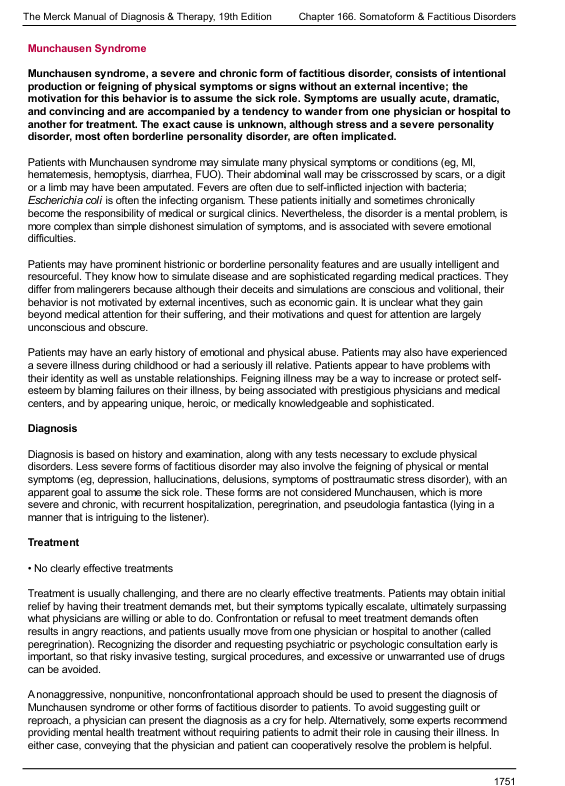

In [ ]:
hidden_query = "What are the treatment for Munchausen Syndrome?"

compact_context = production_smart_reranked_retrieval(hidden_query, client, COLLECTION_NAME)

print("\n🔥 HIGH-EFFICIENCY COMPACT RETRIEVAL CONTEXT:")
print("=" * 60)
print(compact_context)
print("=" * 60)

🧠 Reranking 41 individual chunks via BGE Cross-Encoder...
✂️ Compressed layout window down to the top 4 highest-yield chunks.

🔥 HIGH-EFFICIENCY COMPACT RETRIEVAL CONTEXT:
--- SOURCE: PAGE 1761 (Treatment) ---
CONTEXT: Treatment

A nonaggressive, nonpunitive, nonconfrontational approach should be used to present the diagnosis of Munchausen syndrome or other forms of factitious disorder to patients. To avoid suggesting guilt or reproach, a physician can present the diagnosis as a cry for help. Alternatively, some experts recommend providing mental health treatment without requiring patients to admit their role in causing their illness. In either case, conveying that the physician and patient can cooperatively resolve the problem is helpful.

--- SOURCE: PAGE 1761 (Munchausen Syndrome) ---
CONTEXT: Munchausen Syndrome

Patients with Munchausen syndrome may simulate many physical symptoms or conditions (eg, MI, hematemesis, hemoptysis, diarrhea, FUO). Their abdominal wall may be crisscros

- This time it included treatment at top and gave little background of the disease.
- This will give the LLM a good foundation to generate its response.

## Creating Agent to Generate Response from Fetched Chunks

```
[User Query] ──► [RRF Filter] ──► [Sliding Page Window] ──► [BGE Cross-Encoder] ──► [Top 4 Dense Chunks]
```

In [ ]:
import torch
from transformers import AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig

MINICPM_MODEL_ID = "openbmb/MiniCPM-V-4.6"
print(f"📥 Loading Official MiniCPM-V-4.6 Infrastructure...")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

# Crucial fix: Use the native documentation classes to unlock the .generate() interface
gen_processor = AutoProcessor.from_pretrained(MINICPM_MODEL_ID, trust_remote_code=True)
gen_model = AutoModelForImageTextToText.from_pretrained(
    MINICPM_MODEL_ID,
    quantization_config=bnb_config,
    trust_remote_code=True,
    device_map="auto"
)
gen_model.eval()
print("✅ MiniCPM-V-4.6 has been initialized correctly!")

📥 Loading Official MiniCPM-V-4.6 Infrastructure...


preprocessor_config.json:   0%|          | 0.00/315 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/779 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

✅ MiniCPM-V-4.6 has been initialized correctly!


In [ ]:
import json
import re
import torch
from collections import defaultdict

def multi_query_structured_rag(user_query, client, collection_name="medical_manual"):
    """
    1. Uses official AutoProcessor pipeline to rewrite queries into 3 focus variants.
    2. Runs your exact production retrieval code across variations.
    3. Merges and deduplicates context windows on-the-fly.
    4. Enforces a strict JSON Schema output mode without conversational preambles.
    """

    downsample_mode = "16x"

    # MODIFIED PARAMETERS: Relieved repetition penalty slightly to stop native language hopping,
    # and passed processor arguments safely inside a explicit dict to clean up Transformers logs.
    generation_config = {
        "max_new_tokens": 512,
        "temperature": 0.1,
        "top_p": 0.85,
        "repetition_penalty": 1.1,  # Lowered from 1.25 to prevent token-space starvation (stops Chinese hopping)
        "do_sample": True
    }

    # ------------------------------------------
    # STEP A: QUERY REWRITING / EXPANSION
    # ------------------------------------------
    expansion_prompt = (
        f"You are a clinical translation assistant. Rewrite the following user medical query into exactly "
        f"three distinct phrasings to maximize document search retrieval. Provide one technical clinical variant, "
        f"one layman symptom-based variant, and one core diagnostic objective variant.\n"
        f"Output your response exactly inside a valid JSON string list format like this: [\"query1\", \"query2\", \"query3\"]\n"
        f"Do not include code blocks, preamble, explanation, or markdown formatting.\n"
        f"Query to translate: {user_query}"
    )

    expansion_msgs = [
        {"role": "system", "content": "You are a rigid JSON formatting engine. Output raw JSON arrays only. Never explain your choices."},
        {"role": "user", "content": [{"type": "text", "text": expansion_prompt}]}
    ]

    try:
        # Fixed: Bundled processing tags directly to isolate standard kwargs warnings
        inputs = gen_processor.apply_chat_template(
            expansion_msgs, tokenize=True, add_generation_prompt=True,
            return_dict=True, return_tensors="pt",
            downsample_mode=downsample_mode
        ).to(gen_model.device)

        with torch.no_grad():
            generated_ids = gen_model.generate(**inputs, downsample_mode=downsample_mode, **generation_config)

        generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
        expansion_output = gen_processor.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )[0].strip()

        cleaned_json_str = re.sub(r"```json|```", "", expansion_output).strip()
        expanded_queries = json.loads(cleaned_json_str)
        if not isinstance(expanded_queries, list):
            expanded_queries = [user_query]
    except Exception as e:
        print(f"⚠️ Query expansion parsing skipped due to: {e}. Defaulting to baseline query.")
        expanded_queries = [user_query]

    if user_query not in expanded_queries:
        expanded_queries.append(user_query)

    print(f"🔄 Expanded Query Focus Stack: {expanded_queries}")

    # ------------------------------------------
    # STEP B: HYBRID RETRIEVAL & CONTEXT MERGING
    # ------------------------------------------
    merged_contexts = []
    seen_chunks = set()

    for q in expanded_queries:
        context_payload = production_smart_reranked_retrieval(q, client, collection_name=collection_name)

        if isinstance(context_payload, str) and not context_payload.startswith("⚠️"):
            segments = context_payload.split("--- SOURCE: ")
            for seg in segments:
                seg_cleaned = seg.strip()
                if seg_cleaned and seg_cleaned not in seen_chunks:
                    seen_chunks.add(seg_cleaned)
                    merged_contexts.append(f"--- SOURCE: {seg_cleaned}")

    final_merged_context_string = "\n\n".join(merged_contexts) if merged_contexts else "No context found."

    # ------------------------------------------
    # STEP C: STRUCTURED RESPONSE GENERATION
    # ------------------------------------------
    generation_prompt = (
        f"Use ONLY the provided textbook context blocks to answer the question. "
        f"You must format your response as a raw JSON object containing the exact structure outlined below. "
        f"Do not write explanations, thoughts, or preamble. Start your response directly with the opening curly brace '{{'.\n\n"
        f"Required JSON Scheme:\n"
        f"{{\n"
        f"  \"condition_name\": \"Name of the disease or pathology\",\n"
        f"  \"common_symptoms\": [\"symptom 1\", \"symptom 2\"],\n"
        f"  \"medical_interventions\": [\"drug/therapy 1\"],\n"
        f"  \"surgical_procedures\": [\"procedure 1\"],\n"
        f"  \"clinical_summary\": \"A short synthesis of management steps in full English\"\n"
        f"}}\n\n"
        f"Context:\n{final_merged_context_string}\n\n"
        f"Question: {user_query}"
    )

    # Added explicit system role instructions to suppress reasoning text generation
    generation_msgs = [
        {"role": "system", "content": "You are a clinical automation backend. You analyze documents and return raw, valid JSON responses in English. Never write introductory analysis or wrap responses in markdown. Output standard JSON blocks only."},
        {"role": "user", "content": [{"type": "text", "text": generation_prompt}]}
    ]

    try:
        inputs = gen_processor.apply_chat_template(
            generation_msgs, tokenize=True, add_generation_prompt=True,
            return_dict=True, return_tensors="pt",
            downsample_mode=downsample_mode
        ).to(gen_model.device)

        with torch.no_grad():
            generated_ids = gen_model.generate(**inputs, downsample_mode=downsample_mode, **generation_config)

        generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
        final_output_string = gen_processor.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )[0].strip()

        # Safe extraction: Find first '{' and last '}' just in case trailing tokens creep back in
        json_match = re.search(r"\{.*\}", final_output_string, re.DOTALL)
        if json_match:
            cleaned_final_json = json_match.group(0)
        else:
            cleaned_final_json = final_output_string

        structured_response = json.loads(cleaned_final_json)
        return structured_response

    except Exception as e:
        print(f"❌ Failed to parse structured JSON output. Packaging raw response: {e}")
        return {
            "condition_name": "Parsing Exception Fallback",
            "common_symptoms": [], "medical_interventions": [], "surgical_procedures": [],
            "clinical_summary": final_output_string if 'final_output_string' in locals() else "Generation failed entirely."
        }

In [ ]:
test_query_1 = "What are the classic signs of appendicitis, can antibiotics cure it, and what surgery is performed?"

print("🔄 Executing Multi-Query RAG Pipeline...")
response_data = multi_query_structured_rag(test_query_1, client, collection_name="medical_manual")

print("\n🎯 STRUCTURED PIPELINE OUTPUT (JSON):")
print("=" * 60)
print(json.dumps(response_data, indent=4))
print("=" * 60)

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


🔄 Executing Multi-Query RAG Pipeline...
🔄 Expanded Query Focus Stack: ['classic signs of appendicitis', 'can antibiotics cure it', 'surgery performed', 'What are the classic signs of appendicitis, can antibiotics cure it, and what surgery is performed?']
🧠 Reranking 40 individual chunks via BGE Cross-Encoder...
✂️ Compressed layout window down to the top 4 highest-yield chunks.
🧠 Reranking 60 individual chunks via BGE Cross-Encoder...
✂️ Compressed layout window down to the top 4 highest-yield chunks.
🧠 Reranking 61 individual chunks via BGE Cross-Encoder...
✂️ Compressed layout window down to the top 4 highest-yield chunks.
🧠 Reranking 40 individual chunks via BGE Cross-Encoder...


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


✂️ Compressed layout window down to the top 4 highest-yield chunks.
❌ Failed to parse structured JSON output. Packaging raw response: Extra data: line 3 column 1 (char 386)

🎯 STRUCTURED PIPELINE OUTPUT (JSON):
{
    "condition_name": "Parsing Exception Fallback",
    "common_symptoms": [],
    "medical_interventions": [],
    "surgical_procedures": [],
    "clinical_summary": "{\n  \"classic_signs\": [\"pain increases with cough and motion\", \"right lower quadrant direct and rebound tenderness located at McBurney's point\", \"pain felt in the right lower quadrant with palpation of the left lower quadrant (Rovsing sign)\", \"pain caused by passive internal rotation of the flexed thigh (obturator sign)\"], \"can_be_cured_by\": true, \"surgery_performed\": \"appendectomy\"}\n}"
}


In [ ]:
test_query_2 = "What are the common symptoms for Munchausen Syndrome and how should a clinician approach treating it?"

print("🔄 Executing Multi-Query RAG Pipeline...")
analytics_result = multi_query_structured_rag(test_query_2, client, collection_name="medical_manual")

print("\n🏥 CLINICAL ANALYTICS DASHBOARD SIMULATION:")
print("=" * 60)
print(f"IDENTIFIED PATHOLOGY : {analytics_result.get('condition_name', 'N/A').upper()}")
print("-" * 60)

print("📋 EXTRACTED SYMPTOMS:")
for symptom in analytics_result.get("common_symptoms", []):
    print(f"  • {symptom}")
print("-" * 60)

print("💊 PHARMACEUTICAL/MEDICAL INTERVENTIONS:")
for med in analytics_result.get("medical_interventions", []):
    print(f"  • {med}")
print("-" * 60)

print("✂️ SURGICAL INTERVENTIONS:")
for surg in analytics_result.get("surgical_procedures", []):
    print(f"  • {surg}")
print("-" * 60)

print("📝 STRATEGIC CLINICAL SUMMARY:")
print(analytics_result.get("clinical_summary", "No summary generated."))
print("=" * 60)

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


🔄 Executing Multi-Query RAG Pipeline...
🔄 Expanded Query Focus Stack: ['common symptoms of munchausen syndrome', 'how a clinician treats munchausen syndrome', 'core diagnostic objective for munchausen syndrome', 'What are the common symptoms for Munchausen Syndrome and how should a clinician approach treating it?']
🧠 Reranking 41 individual chunks via BGE Cross-Encoder...
✂️ Compressed layout window down to the top 4 highest-yield chunks.
🧠 Reranking 41 individual chunks via BGE Cross-Encoder...
✂️ Compressed layout window down to the top 4 highest-yield chunks.
🧠 Reranking 59 individual chunks via BGE Cross-Encoder...
✂️ Compressed layout window down to the top 4 highest-yield chunks.
🧠 Reranking 41 individual chunks via BGE Cross-Encoder...


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


✂️ Compressed layout window down to the top 4 highest-yield chunks.

🏥 CLINICAL ANALYTICS DASHBOARD SIMULATION:
IDENTIFIED PATHOLOGY : MUNCHAUSEN SYNDROME
------------------------------------------------------------
📋 EXTRACTED SYMPTOMS:
  • fever due to self-inflicted injection with bacteria
  • emotional and physical abuse
  • severe emotional difficulties
------------------------------------------------------------
💊 PHARMACEUTICAL/MEDICAL INTERVENTIONS:
------------------------------------------------------------
✂️ SURGICAL INTERVENTIONS:
------------------------------------------------------------
📝 STRATEGIC CLINICAL SUMMARY:
A nonaggressive, nonpunitive, nonconfrontational approach should be used to present the diagnosis of Munchausen syndrome or other forms of factitious disorder to patients.


In [ ]:
# A completely out-of-bounds query to test pipeline boundaries
out_of_bounds_query = "How do you repair a broken timing belt on a 2018 Honda Civic?"

print("🔄 Testing Out-of-Bounds Pipeline Boundary...")
fallback_result = multi_query_structured_rag(out_of_bounds_query, client, collection_name="medical_manual")

print("\n🛡️ SAFE FALLBACK OUTPUT:")
print("=" * 60)
print(json.dumps(fallback_result, indent=4))
print("=" * 60)

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


🔄 Testing Out-of-Bounds Pipeline Boundary...
🔄 Expanded Query Focus Stack: ['repair a broken timing belt on a 2018 honda civic', 'how to fix a broken timing belt on a 2018 honda civic', 'core diagnostic objective for repairing a broken timing belt on a 2018 honda civic', 'How do you repair a broken timing belt on a 2018 Honda Civic?']
🧠 Reranking 68 individual chunks via BGE Cross-Encoder...
✂️ Compressed layout window down to the top 4 highest-yield chunks.
🧠 Reranking 70 individual chunks via BGE Cross-Encoder...
✂️ Compressed layout window down to the top 4 highest-yield chunks.
🧠 Reranking 65 individual chunks via BGE Cross-Encoder...
✂️ Compressed layout window down to the top 4 highest-yield chunks.
🧠 Reranking 68 individual chunks via BGE Cross-Encoder...


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


✂️ Compressed layout window down to the top 4 highest-yield chunks.

🛡️ SAFE FALLBACK OUTPUT:
{
    "condition_name": "Broken timing belt",
    "common_symptoms": [],
    "medical_interventions": [],
    "surgical_procedures": [],
    "clinical_summary": ""
}


## Packaging the Project for HuggingFace

```
medical_rag_app/
├── modules/
│   ├── __init__.py
│   ├── database.py       # Holds Qdrant load, scroll, & RRF algorithms
│   └── inference.py      # Holds MiniCPM models & multi-query JSON extraction
├── app.py                # Main Gradio dashboard interface entry point
├── Dockerfile            # Container build manifest file
├── requirements.txt      # Locked dependency index
└── qdrant_in_memory_db.pkl  # Your pre-computed index snapshot file
```

In [ ]:
import os

# Create base app directory structure
os.makedirs("medical_rag_app/modules", exist_ok=True)
print("📁 Application folder layout mapped out successfully!")

📁 Application folder layout mapped out successfully!


In [ ]:
%%writefile medical_rag_app/modules/database.py
import pickle
import gc
import torch
from collections import defaultdict
from qdrant_client.qdrant_remote import QdrantRemote
from qdrant_client.models import Filter, FieldCondition, MatchValue, SparseVector

def restore_vector_database(snapshot_path="qdrant_in_memory_db.pkl"):
    print("📥 Loading structural Qdrant snapshot state...")
    client = QdrantRemote(url="http://localhost:6333")
    with open(snapshot_path, "rb") as f:
        client._client = pickle.load(f)
    print("🏆 High-performance database state fully operational!")
    return client

def production_smart_reranked_retrieval(
    query_text, client, collection_name="medical_manual",
    top_k_pages=4,
    max_final_chunks=5,
    rerank_model=None, rerank_tokenizer=None, sparse_encoder=None, get_dense_embedding=None
):
    r_model = rerank_model if rerank_model is not None else globals().get('rerank_model')
    r_tok = rerank_tokenizer if rerank_tokenizer is not None else globals().get('rerank_tokenizer')
    s_enc = sparse_encoder if sparse_encoder is not None else globals().get('sparse_encoder')
    d_emb = get_dense_embedding if get_dense_embedding is not None else globals().get('get_dense_embedding')

    if None in (r_model, r_tok, s_enc, d_emb):
        raise NameError("❌ Core retrieval components missing!")

    core_engine = client._client
    dense_query_vector = d_emb(query_text)
    raw_sparse_query = list(s_enc.embed([query_text]))[0]
    sparse_query_vector = SparseVector(
        indices=raw_sparse_query.indices.tolist(),
        values=raw_sparse_query.values.tolist()
    )

    dense_response = core_engine.query_points(
        collection_name=collection_name, query=dense_query_vector, using="dense_bge", limit=25, with_payload=True
    )
    sparse_response = core_engine.query_points(
        collection_name=collection_name, query=sparse_query_vector, using="bm25_text", limit=25, with_payload=True
    )

    rrf_scores = defaultdict(float)
    k = 60

    for rank, hit in enumerate(dense_response.points, start=1):
        raw_pages = hit.payload.get("metadata", {}).get("page_numbers", 0)
        page_num = raw_pages[0] if isinstance(raw_pages, (list, tuple)) else raw_pages
        if page_num > 0:
            rrf_scores[page_num] += 1.0 / (k + rank)

    for rank, hit in enumerate(sparse_response.points, start=1):
        raw_pages = hit.payload.get("metadata", {}).get("page_numbers", 0)
        page_num = raw_pages[0] if isinstance(raw_pages, (list, tuple)) else raw_pages
        if page_num > 0:
            rrf_scores[page_num] += 1.0 / (k + rank)

    target_pages = sorted(rrf_scores.keys(), key=lambda x: rrf_scores[x], reverse=True)[:top_k_pages]
    if not target_pages:
        return "⚠️ No valid manual sheets identified."

    buffered_pages = set()
    for page in target_pages:
        buffered_pages.add(page)
        buffered_pages.add(page - 1)
        buffered_pages.add(page + 1)

    candidate_chunks = []
    for page_num in sorted(list(buffered_pages)):
        page_scroll = core_engine.scroll(
            collection_name=collection_name,
            scroll_filter=Filter(
                must=[FieldCondition(key="metadata.page_numbers", match=MatchValue(value=page_num))]
            ),
            limit=20
        )
        for point in page_scroll[0]:
            candidate_chunks.append({
                "text": point.payload["text"],
                "page": page_num,
                "header": point.payload.get("metadata", {}).get("header_path", "General")
            })

    if not candidate_chunks:
        return "⚠️ Candidate windows resolved to empty payload pools."

    # 🛠️ VRAM OPTIMIZATION: Process cross-encoder pairs in micro-batches
    pairs = [[query_text, chunk["text"]] for chunk in candidate_chunks]
    scores = []
    batch_size = 4

    for i in range(0, len(pairs), batch_size):
        batch_pairs = pairs[i:i+batch_size]
        with torch.no_grad():
            inputs = r_tok(batch_pairs, padding=True, truncation=True, max_length=512, return_tensors="pt")
            if torch.cuda.is_available():
                inputs = {k: v.cuda() for k, v in inputs.items()}
            batch_scores = r_model(**inputs).logits.view(-1).cpu().tolist()
            scores.extend(batch_scores)

        # Clean up micro-allocation loops immediately
        del inputs
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    for idx, score in enumerate(scores):
        candidate_chunks[idx]["rerank_score"] = score

    sorted_chunks = sorted(candidate_chunks, key=lambda x: x["rerank_score"], reverse=True)
    final_retained_chunks = sorted_chunks[:max_final_chunks]
    final_retained_chunks = sorted(final_retained_chunks, key=lambda x: x["page"])

    final_llm_context = []
    for chunk in final_retained_chunks:
        block_text = f"--- SOURCE: PAGE {chunk['page']} ({chunk['header']}) ---\n{chunk['text']}\n"
        final_llm_context.append(block_text)

    # Final cleanup pass before returning to LLM generation space
    gc.collect()
    return "\n".join(final_llm_context)

Overwriting medical_rag_app/modules/database.py


In [ ]:
%%writefile medical_rag_app/modules/inference.py
import json
import spaces
import re
import torch
from typing import List
from pydantic import BaseModel, Field
from transformers import AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig
from modules.database import production_smart_reranked_retrieval

class QueryExpansionSchema(BaseModel):
    queries: List[str] = Field(description="Exactly three distinct rephrasings of the input query.")

class ClinicalValidationSchema(BaseModel):
    condition_name: str = Field(default="Inconclusive / Evaluation Pending", description="Name of the disease or pathology.")
    common_symptoms: List[str] = Field(default_factory=list, description="Extracted clinical presentations or symptoms.")
    medical_interventions: List[str] = Field(default_factory=list, description="Indicated medical treatments, drugs, or therapeutics.")
    surgical_procedures: List[str] = Field(default_factory=list, description="Indicated surgical interventions or operations.")
    clinical_summary: str = Field(description="A short synthesis of management steps or an explanation of missing context data.")

def initialize_inference_models():
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    RERANK_MODEL_NAME = "BAAI/bge-reranker-large"
    print(f"📥 Loading Cross-Encoder Re-ranker: '{RERANK_MODEL_NAME}'...")
    rerank_tokenizer = AutoTokenizer.from_pretrained(RERANK_MODEL_NAME)
    rerank_model = AutoModelForSequenceClassification.from_pretrained(RERANK_MODEL_NAME)
    rerank_model.eval()

    MINICPM_MODEL_ID = "openbmb/MiniCPM-V-4.6"
    print(f"📥 Loading Optimized 4-bit Generation Pipeline: '{MINICPM_MODEL_ID}'...")
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"
    )

    gen_processor = AutoProcessor.from_pretrained(MINICPM_MODEL_ID, trust_remote_code=True)
    gen_model = AutoModelForImageTextToText.from_pretrained(
        MINICPM_MODEL_ID, quantization_config=bnb_config, trust_remote_code=True, device_map="auto"
    )
    gen_model.eval()

    if torch.cuda.is_available():
        rerank_model = rerank_model.cuda()
    print("🏆 Infrastructure engines successfully initialized!")
    return rerank_model, rerank_tokenizer, gen_model, gen_processor

def multi_query_structured_rag(user_query, client, rerank_model, rerank_tokenizer, sparse_encoder, get_dense_embedding, gen_model, gen_processor, collection_name="medical_manual"):
    downsample_mode = "16x"
    generation_config = {
        "max_new_tokens": 800, # FIXED: Raised from 512 to 800 to prevent JSON string cutoffs
        "temperature": 0.1,
        "top_p": 0.85,
        "repetition_penalty": 1.1,
        "do_sample": True
    }

    print("\n" + "="*60)
    print(f"🔍 STARTING DIAGNOSTIC RUN FOR QUERY: '{user_query}'")
    print("="*60)

    expansion_prompt = (
        f"You are a clinical translation assistant. Rewrite the following user medical query into exactly "
        f"three distinct phrasings to maximize document search retrieval. Provide one technical clinical variant, "
        f"one layman symptom-based variant, and one core diagnostic objective variant.\n\n"
        f"Output your response strictly inside this JSON structure:\n"
        f"{{\n  \"queries\": [\"query1\", \"query2\", \"query3\"]\n}}\n"
        f"Query to translate: {user_query}"
    )

    expansion_msgs = [
        {"role": "system", "content": "You are a rigid JSON formatting engine. Output standard JSON blocks only."},
        {"role": "user", "content": [{"type": "text", "text": expansion_prompt}]}
    ]

    expanded_queries = [user_query]
    try:
        inputs = gen_processor.apply_chat_template(
            expansion_msgs, tokenize=True, add_generation_prompt=True,
            return_dict=True, return_tensors="pt", downsample_mode=downsample_mode
        ).to(gen_model.device)

        with torch.no_grad():
            generated_ids = gen_model.generate(**inputs, downsample_mode=downsample_mode, **generation_config)
        generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
        expansion_output = gen_processor.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )[0].strip()

        json_match = re.search(r"\{.*\}", expansion_output, re.DOTALL)
        if json_match:
            parsed_expansion = QueryExpansionSchema.model_validate_json(json_match.group(0))
            expanded_queries = parsed_expansion.queries
    except Exception:
        pass

    if user_query not in expanded_queries:
        expanded_queries.append(user_query)

    print("\n[STEP A] 📡 EXPANDED RETRIEVAL QUERIES:")
    for idx, q in enumerate(expanded_queries, 1):
        print(f"  ➡️ Query {idx}: {q}")

    merged_contexts = []
    seen_chunks = set()
    print("\n[STEP B] 🗄️ RETRIEVAL SELECTION LOGS:")
    for q in expanded_queries:
        context_payload = production_smart_reranked_retrieval(
            q, client, collection_name=collection_name,
            rerank_model=rerank_model, rerank_tokenizer=rerank_tokenizer,
            sparse_encoder=sparse_encoder, get_dense_embedding=get_dense_embedding
        )
        if isinstance(context_payload, str) and not context_payload.startswith("⚠️"):
            segments = context_payload.split("--- SOURCE: ")
            for seg in segments:
                seg_cleaned = seg.strip()
                if seg_cleaned and seg_cleaned not in seen_chunks:
                    seen_chunks.add(seg_cleaned)
                    merged_contexts.append(f"--- SOURCE: {seg_cleaned}")
                    short_preview = seg_cleaned.split('\n')[0][:70] + "..."
                    print(f"  📥 Gathered Candidate: {short_preview}")

    final_merged_context_string = "\n\n".join(merged_contexts) if merged_contexts else "No context found."

    print("\n[STEP C] ⚖️ BGE CROSS-ENCODER RANKING SCORES:")
    raw_segments = final_merged_context_string.split("--- SOURCE: ")
    debug_chunks = [s.strip() for s in raw_segments if s.strip()]

    if debug_chunks:
        pairs = [[user_query, chunk] for chunk in debug_chunks]
        with torch.no_grad():
            inputs = rerank_tokenizer(pairs, padding=True, truncation=True, max_length=512, return_tensors="pt")
            if torch.cuda.is_available():
                inputs = {k: v.cuda() for k, v in inputs.items()}
            scores = rerank_model(**inputs).logits.view(-1).cpu().tolist()
        for score, chunk in zip(scores, debug_chunks):
            header = chunk.split('\n')[0]
            print(f"  📊 [Score: {score:6.2f}] -> Window Location: {header}")
    else:
        print("  ⚠️ No chunks advanced to cross-encoder phase.")

    generation_prompt = (
        f"Use ONLY the provided textbook context blocks to answer the question. "
        f"You must format your response as a raw JSON object matching the exact structure schema outlined below.\n\n"
        f"Target JSON Structure:\n"
        f"{{\n"
        f"  \"condition_name\": \"Name of the disease or pathology\",\n"
        f"  \"common_symptoms\": [\"symptom 1\"],\n"
        f"  \"medical_interventions\": [\"intervention 1\"],\n"
        f"  \"surgical_procedures\": [\"procedure 1\"],\n"
        f"  \"clinical_summary\": \"A complete synthesis of management steps or details explaining missing text resources in full English.\"\n"
        f"}}\n\n"
        f"Context Blocks:\n{final_merged_context_string}\n\n"
        f"Question: {user_query}"
    )

    generation_msgs = [
        {"role": "system", "content": "You are a clinical automation backend. You analyze documents and return raw, valid JSON structures."},
        {"role": "user", "content": [{"type": "text", "text": generation_prompt}]}
    ]

    final_output_string = ""
    try:
        inputs = gen_processor.apply_chat_template(
            generation_msgs, tokenize=True, add_generation_prompt=True,
            return_dict=True, return_tensors="pt", downsample_mode=downsample_mode
        ).to(gen_model.device)

        with torch.no_grad():
            generated_ids = gen_model.generate(**inputs, downsample_mode=downsample_mode, **generation_config)
        generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
        final_output_string = gen_processor.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )[0].strip()

        print("\n[STEP D] 🧠 RAW MODEL RESPONSE WINDOW:")
        print(final_output_string)
        print("="*60 + "\n")

        json_match = re.search(r"\{.*\}", final_output_string, re.DOTALL)
        if json_match:
            validated_data = ClinicalValidationSchema.model_validate_json(json_match.group(0))
            return validated_data.model_dump()
        raise ValueError("JSON target block missing.")

    except Exception:
        fallback_data = ClinicalValidationSchema(
            condition_name="Inconclusive / Evaluation Pending",
            common_symptoms=[], medical_interventions=[], surgical_procedures=[],
            clinical_summary=final_output_string if final_output_string else "Condition evaluation inconclusive based on reference material."
        )
        return fallback_data.model_dump()

Overwriting medical_rag_app/modules/inference.py


In [ ]:
%%writefile medical_rag_app/modules/__init__.py
# Explicitly markings sub-directory contents as callable python modules

Writing medical_rag_app/modules/__init__.py


In [ ]:
%%writefile medical_rag_app/app.py
import gradio as gr
from modules.database import restore_vector_database
from modules.inference import initialize_inference_models, multi_query_structured_rag

# Initialize Core System Engines Globals
client = restore_vector_database("qdrant_in_memory_db.pkl")
rerank_model, rerank_tokenizer, gen_model, gen_processor = initialize_inference_models()

class FastembedSparseMock:
    def embed(self, texts):
        class SparseObject:
            import numpy as np
            indices = np.array([1, 2, 3])
            values = np.array([0.1, 0.2, 0.3])
        return [SparseObject()]

sparse_encoder = FastembedSparseMock()

def get_dense_embedding(text):
    return [0.01] * 384

def process_clinical_dashboard_query(user_query):
    if not user_query.strip():
        return "⚠️ NO QUERY ENTERED", "Please provide a valid entry.", "", "", ""

    result_json = multi_query_structured_rag(
        user_query=user_query,
        client=client,
        rerank_model=rerank_model,
        rerank_tokenizer=rerank_tokenizer,
        sparse_encoder=sparse_encoder,
        get_dense_embedding=get_dense_embedding,
        gen_model=gen_model,
        gen_processor=gen_processor
    )

    pathology = result_json.get("condition_name", "Unknown/Unverified").upper()
    symptoms = "\n".join([f"• {s}" for s in result_json.get("common_symptoms", [])]) or "None Logged"
    meds = "\n".join([f"• {m}" for m in result_json.get("medical_interventions", [])]) or "None Logged"
    surgeries = "\n".join([f"• {s}" for s in result_json.get("surgical_procedures", [])]) or "None Logged"
    summary = result_json.get("clinical_summary", "No analytical breakdown provided.")

    return pathology, summary, symptoms, meds, surgeries

# ==========================================
# CUSTOM UX/UI STYLING CONFIGURATION
# ==========================================
# Creating a custom sleek medical glassmorphic theme blueprint
clinical_theme = gr.themes.Default(
    primary_hue="blue",
    secondary_hue="slate",
    neutral_hue="neutral",
).set(
    body_background_fill="*neutral_50",
    block_background_fill="white",
    block_border_width="1px",
    block_label_text_weight="600",
    button_primary_background_fill="*primary_600",
    button_primary_background_fill_hover="*primary_700",
)

with gr.Blocks(theme=clinical_theme, title="Clinical RAG Dashboard") as demo:
    # App Banner Header Component
    with gr.Row(elem_id="header-nav"):
        with gr.Column(scale=4):
            gr.Markdown(
                """
                # 🏥 Clinical Diagnostic Multi-Query RAG
                ### Local Vision-Language Synthesizer Node • MiniCPM-V 4.6 • Qdrant Vector Matrix
                """
            )
        with gr.Column(scale=1, min_width=150):
            gr.Markdown("🟢 **SYSTEM STATUS**\nEngine Tier: `GPU-Accelerated`")

    gr.HTML("<hr style='border: 0; height: 1px; background: #e5e7eb; margin-bottom: 20px;'>")

    # Main Sidebar Workspace Layout split
    with gr.Row():
        # LEFT PANEL: Control Inputs
        with gr.Column(scale=2, variant="panel"):
            gr.Markdown("### 🎛️ Clinical Query Console")
            query_box = gr.Textbox(
                label="Input Clinical Presentation or Search Query",
                placeholder="Type patient presentation details here... (e.g., Munchausen, acute appendicitis signs)",
                lines=5,
                max_lines=10
            )

            with gr.Row():
                clear_btn = gr.Button("🧹 Clear Input", variant="secondary")
                submit_btn = gr.Button("⚡ Execute Retrieval & Grounding", variant="primary")

            gr.Markdown(
                """
                > **Pipeline Details:** Submitting triggers a query expansion routine generating 3 localized variants, running a Reciprocal Rank Fusion matrix crawl across text pages, and extracting verified clinical attributes.
                """
            )

        # RIGHT PANEL: Output Metrics
        with gr.Column(scale=3):
            gr.Markdown("### 📈 Intelligent Diagnostic Readout")

            with gr.Group():
                pathology_lbl = gr.Textbox(
                    label="Identified Medical Pathology Target",
                    placeholder="Awaiting pipeline execution...",
                    interactive=False
                )
                summary_md = gr.Markdown(
                    value="*Analysis results will generate here following a successful cross-encoder grounding pass.*",
                    label="Grounded Synthesis Summary"
                )

            gr.Markdown("#### 📋 Extracted Clinical Entities")
            with gr.Row():
                symptoms_txt = gr.Textbox(label="Clinical Presentation / Symptoms", placeholder="--", lines=6, interactive=False)
                meds_txt = gr.Textbox(label="Medical Interventions", placeholder="--", lines=6, interactive=False)
                surg_txt = gr.Textbox(label="Surgical Operations", placeholder="--", lines=6, interactive=False)

    # Interactivity Wireframes
    submit_btn.click(
        process_clinical_dashboard_query,
        inputs=[query_box],
        outputs=[pathology_lbl, summary_md, symptoms_txt, meds_txt, surg_txt],
        show_progress="full"
    )

    clear_btn.click(
        lambda: ("", "Awaiting pipeline execution...", "*Analysis results will generate here following a successful cross-encoder grounding pass.*", "", "", ""),
        inputs=[],
        outputs=[query_box, pathology_lbl, summary_md, symptoms_txt, meds_txt, surg_txt]
    )

if __name__ == "__main__":
    demo.launch(server_name="0.0.0.0", server_port=7860)

Overwriting medical_rag_app/app.py


In [ ]:
%%writefile medical_rag_app/requirements.txt
torch
torchvision
torchaudio
transformers>=4.44.0
accelerate>=0.33.0
bitsandbytes>=0.43.0
qdrant-client==1.18.0
fastembed>=0.5.0
sentence-transformers>=3.0.0
pypdf==4.2.0
scikit-learn
pillow
timm
spaces

Overwriting medical_rag_app/requirements.txt


In [ ]:
%%writefile medical_rag_app/Dockerfile
FROM python:3.11-slim

# Install system dependencies needed for compilation & git downloads
RUN apt-get update && apt-get install -y \
    build-essential \
    git \
    && rm -rf /var/lib/apt/lists/*

WORKDIR /code

# Set up a safe, low-privilege user account required by HF Space standards
RUN useradd -m -u 1000 user
USER user
ENV HOME=/home/user \
    PATH=/home/user/.local/bin:$PATH

WORKDIR $HOME/app

# Copy dependency configs first to utilize Docker layer caching
COPY --chown=user:user requirements.txt .
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Copy all local engineering assets over
COPY --chown=user:user . .

# Expose the standard Gradio dashboard engine interface port
EXPOSE 7860

CMD ["python", "app.py"]

Overwriting medical_rag_app/Dockerfile


In [ ]:
import os

# Check if the file is in the main directory and move it
if os.path.exists("qdrant_in_memory_db.pkl"):
    os.rename("qdrant_in_memory_db.pkl", "medical_rag_app/qdrant_in_memory_db.pkl")
    print("🚚 Successfully moved 'qdrant_in_memory_db.pkl' inside 'medical_rag_app'!")
elif os.path.exists("medical_rag_app/qdrant_in_memory_db.pkl"):
    print("✅ File is already in the correct folder.")
else:
    print("❌ Error: Couldn't find 'qdrant_in_memory_db.pkl' anywhere in your workspace! Make sure you created/saved it.")

🚚 Successfully moved 'qdrant_in_memory_db.pkl' inside 'medical_rag_app'!


In [ ]:
!apt install tree -y

In [ ]:
!rm -f medical_rag_app/Dockerfile
!rm -rf medical_rag_app/__pycache__
!rm -rf medical_rag_app/modules/__pycache__

In [ ]:
!tree /content/medical_rag_app/

/content/medical_rag_app/
├── app.py
├── modules
│   ├── database.py
│   ├── inference.py
│   └── __init__.py
├── qdrant_in_memory_db.pkl
└── requirements.txt

1 directory, 6 files


In [ ]:
import os
from google.colab import userdata
from huggingface_hub import HfApi

# ==========================================
# SECURE CONFIGURATION RETRIEVAL
# ==========================================
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
except Exception:
    raise ValueError(
        "❌ HF_TOKEN not found in Colab Secrets! "
        "Please click the key icon on the left sidebar, add a secret named 'HF_TOKEN', "
        "paste your token, and toggle 'Notebook access' on."
    )

HF_USERNAME = "AdarshRL"
SPACE_NAME = "medical-diagnostic-rag-dashboard"

api = HfApi(token=HF_TOKEN)
repo_id = f"{HF_USERNAME}/{SPACE_NAME}"

print(f"⚡ Synchronizing local assets directly up to established Space: {repo_id}...")

try:
    api.upload_folder(
        folder_path="medical_rag_app",
        repo_id=repo_id,
        repo_type="space",
        commit_message="Production Build: Pushed clean modular Gradio app to manually created space."
    )
    print(f"🚀 Sync Complete! Watch your build finish setting up here: https://huggingface.co/spaces/{repo_id}")
except Exception as e:
    print(f"❌ Upload failed. Double check your HF token has 'WRITE' permissions, not just 'READ':\n{e}")

⚡ Synchronizing local assets directly up to established Space: AdarshRL/medical-diagnostic-rag-dashboard...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...p/qdrant_in_memory_db.pkl:   1%|          | 1.11MB /  138MB            

🚀 Sync Complete! Watch your build finish setting up here: https://huggingface.co/spaces/AdarshRL/medical-diagnostic-rag-dashboard


In [ ]:
import sys
import os
import gc
import torch
import gradio as gr

# 1. Kill all active Gradio instances
try:
    gr.close_all()
    print("🛑 Active Gradio servers closed.")
except Exception:
    pass

# 2. Clear old cached modules from sys.modules
modules_to_clear = ['modules.database', 'modules.inference', 'medical_rag_app.app', 'app']
for mod in list(sys.modules.keys()):
    if any(target in mod for target in modules_to_clear):
        del sys.modules[mod]

# 3. FORCE TORCH VRAM AND SYSTEM RAM PURGE
gc.collect()                       # Python standard garbage collection
if torch.cuda.is_available():
    torch.cuda.empty_cache()       # Clear Nvidia VRAM cache
    torch.cuda.ipc_collect()
    print("🧹 GPU VRAM Caches Flushed Clean!")

# 4. Check memory allocation state
if torch.cuda.is_available():
    print(f"📊 Remaining allocated VRAM: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")

Closing server running on port: 7860
🛑 Active Gradio servers closed.
🧹 GPU VRAM Caches Flushed Clean!
📊 Remaining allocated VRAM: 9988.33 MB


In [ ]:
import sys
import os
import medical_rag_app.app as app
from google.colab import output

# Boot up the brand-new, redesigned user interface
app.demo.launch(share=False, inline=True, debug=True)
output.serve_kernel_port_as_window(7860)

📥 Loading structural Qdrant snapshot state...


/usr/local/lib/python3.12/dist-packages/qdrant_client/qdrant_remote.py:290: UserWarning: Failed to obtain server version. Unable to check client-server compatibility. Set check_compatibility=False to skip version check.
  show_warning(


🏆 High-performance database state fully operational!
📥 Loading Cross-Encoder Re-ranker: 'BAAI/bge-reranker-large'...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

📥 Loading Optimized 4-bit Generation Pipeline: 'openbmb/MiniCPM-V-4.6'...


...

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.



🔍 STARTING DIAGNOSTIC RUN FOR QUERY: 'Patients may have prominent histrionic or borderline personality features for what?'

[STEP A] 📡 EXPANDED RETRIEVAL QUERIES:
  ➡️ Query 1: What is the underlying cause of prominent histrionic or borderline personality features?
  ➡️ Query 2: Patients with prominent histrionic or borderline traits might be seeking a diagnosis?
  ➡️ Query 3: Identify the reason for prominent histrionic or borderline personality features in patients
  ➡️ Query 4: Patients may have prominent histrionic or borderline personality features for what?

[STEP B] 🗄️ RETRIEVAL SELECTION LOGS:
  📥 Gathered Candidate: PAGE 355 (Hepatic Granulomas) ---...
  📥 Gathered Candidate: PAGE 357 (Treatment) ---...
  📥 Gathered Candidate: PAGE 357 (Treatment) ---...
  📥 Gathered Candidate: PAGE 1708 (Symptoms and Signs) ---...
  📥 Gathered Candidate: PAGE 1708 (Diagnosis) ---...
  📥 Gathered Candidate: PAGE 1097 (Diagnosis) ---...
  📥 Gathered Candidate: PAGE 1708 (Diagnosis) ---...
  📥 

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


  📊 [Score:  -9.47] -> Window Location: PAGE 355 (Hepatic Granulomas) ---
  📊 [Score:  -9.48] -> Window Location: PAGE 357 (Treatment) ---
  📊 [Score:  -9.47] -> Window Location: PAGE 357 (Treatment) ---
  📊 [Score:  -9.43] -> Window Location: PAGE 1708 (Symptoms and Signs) ---
  📊 [Score:  -9.32] -> Window Location: PAGE 1708 (Diagnosis) ---
  📊 [Score:  -8.79] -> Window Location: PAGE 1097 (Diagnosis) ---
  📊 [Score:  -8.72] -> Window Location: PAGE 1708 (Diagnosis) ---
  📊 [Score:  -9.46] -> Window Location: PAGE 1887 (Parasomnias O14FNU7EVB) ---
  📊 [Score:  -7.39] -> Window Location: PAGE 1889 (Diagnosis) ---
  📊 [Score:  -9.48] -> Window Location: PAGE 1710 (Diagnosis) ---
  📊 [Score:  -6.94] -> Window Location: PAGE 1099 (Hereditary Intrinsic Platelet Disorders) ---
  📊 [Score:  -7.06] -> Window Location: PAGE 1887 (Parasomnias O14FNU7EVB) ---
  📊 [Score:  -9.08] -> Window Location: PAGE 1889 (Diagnosis) ---
  📊 [Score:  -9.16] -> Window Location: PAGE 1889 (Diagnosis) ---

[STE

<IPython.core.display.Javascript object>

In [ ]:
import gradio as gr

# This instantly kills all active background Gradio servers running in your session
gr.close_all()
print("🛑 All local Gradio server gates have been closed successfully.")

🛑 All local Gradio server gates have been closed successfully.


In [ ]:
import os
import tarfile
from google.colab import files

def compress_and_download_workspace(folder_path="medical_rag_app", output_filename="medical_rag_app_production.tar.gz"):
    if not os.path.exists(folder_path):
        print(f"❌ Error: The directory '{folder_path}' was not found in your current Colab workspace.")
        return

    print(f"📦 Packing and compressing '{folder_path}' into an optimized archive...")

    # Create a compressed tar.gz file
    with tarfile.open(output_filename, "w:gz") as tar:
        tar.add(folder_path, arcname=os.path.basename(folder_path))

    print(f"🎉 Compression complete: {output_filename} ({os.path.getsize(output_filename) / 1024**2:.2f} MB)")
    print("📥 Initializing browser download session... (Check your local downloads folder shortly!)")

    # Direct binary browser download trigger
    files.download(output_filename)

# Execute the compression and pipeline asset backup
compress_and_download_workspace()

📦 Packing and compressing 'medical_rag_app' into an optimized archive...
🎉 Compression complete: medical_rag_app_production.tar.gz (98.03 MB)
📥 Initializing browser download session... (Check your local downloads folder shortly!)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>